<div align="center">
  <img src="https://raw.githubusercontent.com/WSU-AI-in-ME/ai-in-me-1/main/img/wsu_logo_horizontal.png" alt="Wayne State University Logo" width="320">
  <h1>Practice 3: Manufacturing Signals and Feature Engineering</h1>
</div>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WSU-AI-in-ME/ai-in-me-1/blob/main/practice/week03/practice03_manufacturing_signals_and_feature_engineering_solution.ipynb)

[Course Repository](https://github.com/WSU-AI-in-ME/ai-in-me-1) · [Practice Index](https://github.com/WSU-AI-in-ME/ai-in-me-1/blob/main/Practice_index.ipynb)

### ME 5995 - AI in Mechanical Engineering I: Fundamentals of Manufacturing Data Science
**Wayne State University · Optional, ungraded self-study · Normally not submitted**  
**Version: Self-check solution**

Try your selected exercises before consulting the solution. Each answer is one
possible approach. [Return to the starter](https://colab.research.google.com/github/WSU-AI-in-ME/ai-in-me-1/blob/main/practice/week03/practice03_manufacturing_signals_and_feature_engineering.ipynb).

## Student Information

Optional for your personal copy. Double-click this Markdown cell to edit.

**Student name:** Instructor Example  
**WSU AccessID:** example00

## Choose a route

You do **not** need to complete every exercise. This bank contains **25 main exercises
in five independent modules**. Start with a concept you want to understand.

| Route | Exercise links | Count | Estimated time |
|---|---|---:|---|
| Short | [A1](#a1), [A2](#a2), [B1](#b1), [B2](#b2), [C1](#c1), [C2](#c2), [D1](#d1), [D2](#d2), [E1](#e1), [E3](#e3) | 10 | 50–65 min |
| Standard | [A1](#a1), [A2](#a2), [A5](#a5), [B1](#b1), [B2](#b2), [B4](#b4), [C1](#c1), [C2](#c2), [C3](#c3), [D1](#d1), [D2](#d2), [D3](#d3), [E1](#e1), [E3](#e3), [E4](#e4) | 15 | 80–100 min |
| Full | [A1](#a1), [A2](#a2), [A3](#a3), [A4](#a4), [A5](#a5), [B1](#b1), [B2](#b2), [B3](#b3), [B4](#b4), [B5](#b5), [C1](#c1), [C2](#c2), [C3](#c3), [C4](#c4), [C5](#c5), [D1](#d1), [D2](#d2), [D3](#d3), [D4](#d4), [D5](#d5), [E1](#e1), [E2](#e2), [E3](#e3), [E4](#e4), [E5](#e5) | 25 | 120–160 min |
| Debugging | [A4](#a4), [B4](#b4), [C5](#c5), [D3](#d3), [E4](#e4) | 5 | 35–50 min |

Standard is Short plus A5, B4, C3, D3 and E4. Full includes A1–A5 through E1–E5.
Debugging includes numerical and interpretation mistakes, not only syntax errors.
Times include setup, selected plots, reading and self-checking; these are estimates,
not measured student times. Budget about 60/90/140/45 minutes for the four routes.
Skim the purpose comments and run supplied processing; you do not need to reconstruct
it. Reading every supplied line in depth or repeating examples may take longer.

[A: Sampling](#module-a) · [B: Scalars](#module-b) · [C: FFT](#module-c) ·
[D: FFT/STFT](#module-d) · [E: Features](#module-e)

The [PHM transfer T1](#t1) adds about **10–15 minutes**, outside all route counts.
Optional A5 aliasing and B5 crest-factor subparts each add about **5 minutes**;
Full does not require them. Their code is supplied and can be skipped.

## Learning objectives and how to work

Connect sample index to seconds; distinguish offset, variation, RMS and extremes;
predict frequency peaks; locate changes with a spectrogram; and justify feature
choices using relevance, redundancy and engineering meaning.

**Concept → predict → small change → run → observe → explain.**

1. Run the setup inside your selected module. It imports everything that module needs.
2. Read a selected prompt. For [PREDICT], write your initial thought before running.
3. Edit only the short action cell where requested. Supplied processing and plotting
   cells are marked **Provided setup - run unchanged**; run those without rewriting them.
4. Read the output, explain one observation, and then check the solution.

`None` means an unfinished answer. Supplied guards print a reminder and skip its
dependent output; a reminder is not an answer. Debug mistakes appear only in
Markdown or comments. The original starter runs top-to-bottom without errors.
An exercise needs only its module setup, not previous exercise answers.

All main-bank values are **course-created synthetic teaching examples**, not
experimental observations or benchmark labels. Amplitude uses arbitrary units
(a.u.), not a calibrated force or vibration unit. Only optional T1 uses real PHM data.
No data download is needed for Modules A–E or default Run all.

Use NumPy, pandas, Matplotlib and SciPy in Colab or your configured notebook environment.
Install the required packages in your local Python environment. If a requirements.txt
file is provided, you may use it. In Colab, try imports first; no extra installation
cell is needed when the libraries are already available.

<a id="module-a"></a>

# Module A - Sampling and Physical Time

A sample index counts entries; time measures seconds.
At `fs` samples per second, neighboring samples are `1/fs` seconds apart.
`np.arange(N)` produces indices 0 through N-1. Divide indices by fs to get seconds.
**Worked example:** sample index 2 at 500 Hz occurs at 2/500 = 0.004 s.

**Start here:** run this module's setup, then any selected exercise. No earlier module or exercise answer is needed.

In [1]:
# Provided setup - run unchanged.
import numpy as np
import matplotlib.pyplot as plt
# Supplied display settings: readable figures, without changing the data.
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.figsize'] = (9, 3.4)
plt.rcParams['figure.dpi'] = 120

In [2]:
# Provided setup - run unchanged.
fs = 1000
# fs is the synthetic sampling rate in samples/second (Hz), used to obtain seconds.
N = 5
# N is the number of samples, a count rather than a time duration.
sample_index = np.arange(N)
# These five synthetic amplitudes (a.u.) make individual sample markers visible.
sample_values = np.array([0., 1., 0., -1., 0.])
print('Worked example: index 2 at 500 Hz =', 2/500, 's')

Worked example: index 2 at 500 Hz = 0.004 s


<a id="a1"></a>

## A1 - [COMPLETE] Sample index to time

Complete one expression for five sample times at 1000 Hz. Predict the spacing, then run the supplied marker plot. Which time belongs to the first sample?

In [3]:
# Divide sample indices by samples/second to obtain seconds.
time_s = np.arange(N) / fs

Sample times (s): [0.    0.001 0.002 0.003 0.004]


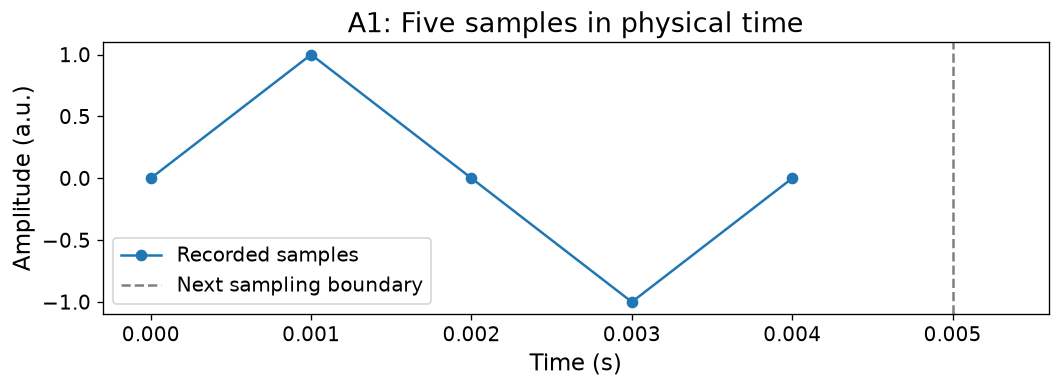

In [4]:
# Provided setup - run unchanged.
if time_s is None:
    print('A1: enter the time expression, then rerun this cell.')
else:
    print('Sample times (s):', time_s)
    fig, ax = plt.subplots()
    ax.plot(time_s, sample_values, 'o-', label='Recorded samples')
    ax.axvline(N/fs, color='gray', linestyle='--', label='Next sampling boundary')
    ax.set(title='A1: Five samples in physical time', xlabel='Time (s)',
           ylabel='Amplitude (a.u.)', xlim=(-0.0003, 0.0056))
    ax.legend(loc='lower left')
    fig.tight_layout()
    plt.show()

**Self-check - one possible answer.** The times are [0, 0.001, 0.002, 0.003, 0.004] s. Adjacent samples are 0.001 s apart. The first index is zero, so its timestamp is zero.

<a id="a2"></a>

## A2 - [INTERPRET] Last timestamp versus duration

Read the supplied timeline. Compare the last observed timestamp with nominal duration. Why is their difference one sampling interval?

Last timestamp / nominal duration (s): 0.004 0.005


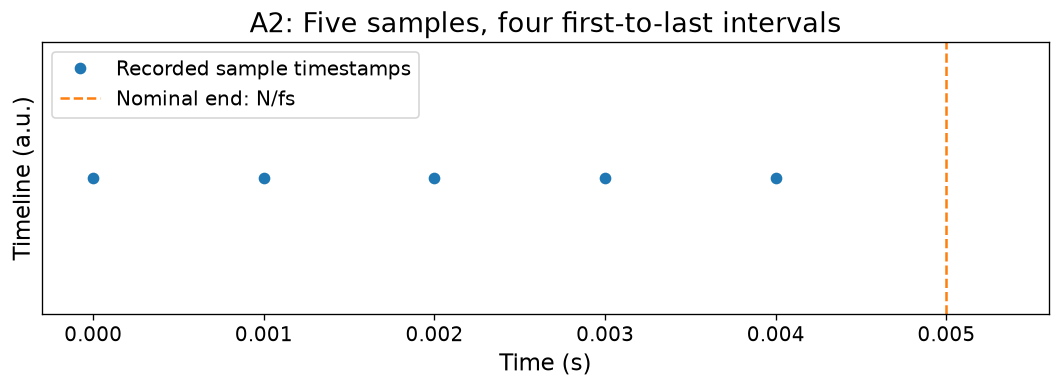

In [5]:
# Provided setup - run unchanged.
# Reconstruct times here; A1's answer is not needed.
A2_time = np.arange(N) / fs
last_time_s = (N - 1) / fs
duration_s = N / fs
print('Last timestamp / nominal duration (s):', last_time_s, duration_s)
fig, ax = plt.subplots()
ax.plot(A2_time, np.zeros(N), 'o', label='Recorded sample timestamps')
ax.axvline(duration_s, color='tab:orange', linestyle='--', label='Nominal end: N/fs')
ax.set(title='A2: Five samples, four first-to-last intervals', xlabel='Time (s)',
       ylabel='Timeline (a.u.)', xlim=(-0.0003, 0.0056), ylim=(-0.5, 0.5))
ax.set_yticks([])
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** The last timestamp is 0.004 s, while nominal duration is 0.005 s. Five samples have four intervals between the first and last points. N/fs includes the interval up to the next sampling boundary; it does not imply that another sample was recorded.

<a id="a3"></a>

## A3 - [CHANGE] Change the assumed sampling rate

Keep the same five values. Run at 1000 Hz, change only the rate to 2000 Hz, then rerun. What happens to nominal duration and the last timestamp? Are new measurements being acquired?

In [6]:
# new_fs changes the assumed samples/second; the five values remain fixed.
new_fs = 2000

Baseline last / duration (s): 0.004 0.005
Changed last / duration (s): 0.002 0.0025


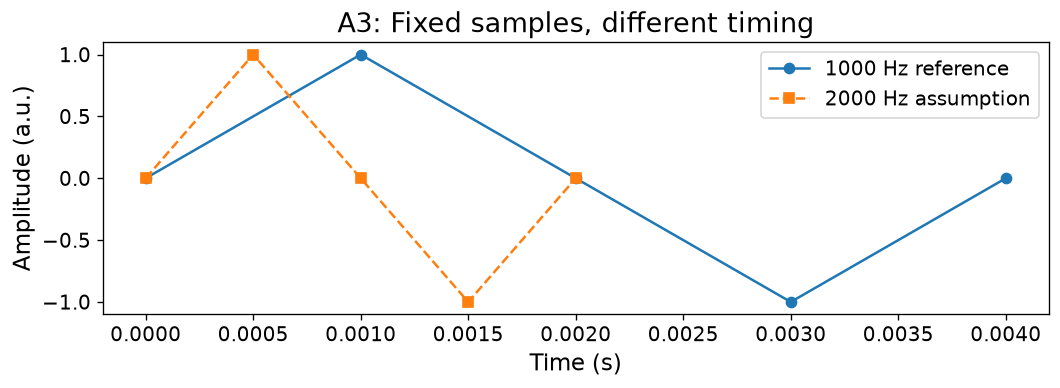

In [7]:
# Provided setup - run unchanged.
reference_time = np.arange(N) / 1000
changed_time = np.arange(N) / new_fs
print('Baseline last / duration (s):', (N-1)/1000, N/1000)
print('Changed last / duration (s):', (N-1)/new_fs, N/new_fs)
fig, ax = plt.subplots()
ax.plot(reference_time, sample_values, 'o-', label='1000 Hz reference')
ax.plot(changed_time, sample_values, 's--', label=f'{new_fs} Hz assumption')
ax.set(title='A3: Fixed samples, different timing', xlabel='Time (s)', ylabel='Amplitude (a.u.)')
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** At 2000 Hz, nominal duration is 0.0025 s and the last timestamp is 0.002 s, both half their 1000 Hz values. The samples have only been assigned different timing; this is neither resampling nor collecting new measurements.

<a id="a4"></a>

## A4 - [DEBUG] Correct the time-axis equation

The following line is intentionally wrong and is not executed:

```python
time_s = np.arange(N) * fs
```

Replace the operator in the action cell, then print your five times. Explain the units.

In [8]:
# Division converts sample counts into seconds.
corrected_time_s = np.arange(N) / fs

In [9]:
# Provided setup - run unchanged.
if corrected_time_s is None:
    print('A4: enter the corrected expression.')
else:
    print('Corrected times (s):', corrected_time_s)

Corrected times (s): [0.    0.001 0.002 0.003 0.004]


**Self-check - one possible answer.** Replace multiplication with division: `np.arange(N) / fs`. Multiplying by samples/second gives neither the correct physical unit nor the correct scale. The corrected timestamps end at 0.004 s.

<a id="a5"></a>

## A5 - [COMPARE] Same sine wave, different point density

Compare a 50 Hz sine at 1000 and 200 Hz over the same 0.1 s. Which changes: the underlying wave, the number of points, or the duration? How does this differ from fixed-N A3?

In [10]:
# Provided setup - run unchanged.
# Both records represent a 50 Hz, amplitude-1 signal over 0.1 seconds.
dense_time = np.arange(2000) / 20000
fast_time = np.arange(100) / 1000
slow_time = np.arange(20) / 200
dense_wave = np.sin(2 * np.pi * 50 * dense_time)
fast_wave = np.sin(2 * np.pi * 50 * fast_time)
slow_wave = np.sin(2 * np.pi * 50 * slow_time)
print('Samples at 1000 / 200 Hz:', len(fast_time), len(slow_time))
print('Nyquist limits (Hz):', 1000/2, 200/2)

Samples at 1000 / 200 Hz: 100 20
Nyquist limits (Hz): 500.0 100.0


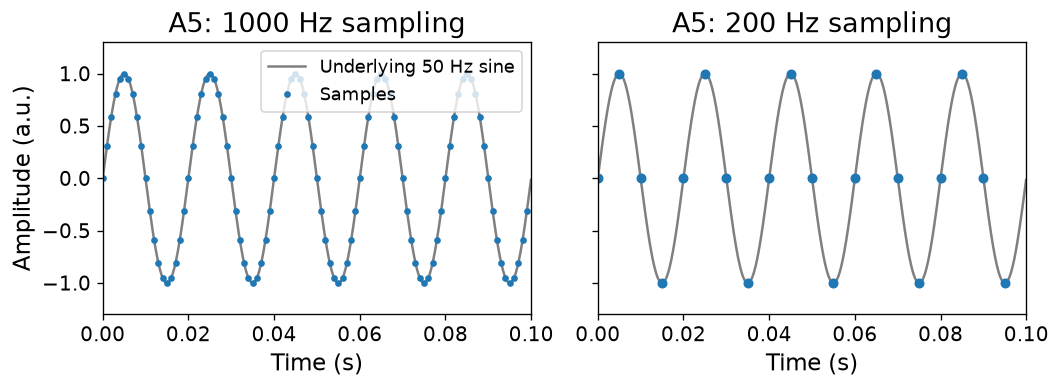

In [11]:
# Provided setup - run unchanged.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4), sharex=True, sharey=True)
ax1.plot(dense_time, dense_wave, color='gray', label='Underlying 50 Hz sine')
ax1.plot(fast_time, fast_wave, 'o', markersize=3, label='Samples')
ax2.plot(dense_time, dense_wave, color='gray', label='Underlying 50 Hz sine')
ax2.plot(slow_time, slow_wave, 'o', markersize=5, label='Samples')
ax1.set(title='A5: 1000 Hz sampling', xlabel='Time (s)', ylabel='Amplitude (a.u.)',
        xlim=(0, 0.1), ylim=(-1.3, 1.3))
ax2.set(title='A5: 200 Hz sampling', xlabel='Time (s)', xlim=(0, 0.1))
ax1.legend(loc='upper right', fontsize=11)
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** There are 100 versus 20 points, but both represent five cycles of the same 50 Hz wave over 0.1 s. The Nyquist limits are 500 and 100 Hz. Here duration is fixed and N changes; A3 fixed N and changed its assumed timing.

### A5 optional challenge: an ambiguous sampled wave

Run unchanged if interested (about 5 extra minutes). At 80 Hz sampling, the Nyquist limit is 40 Hz. Compare the samples with the two reference curves. No aliasing derivation is needed.

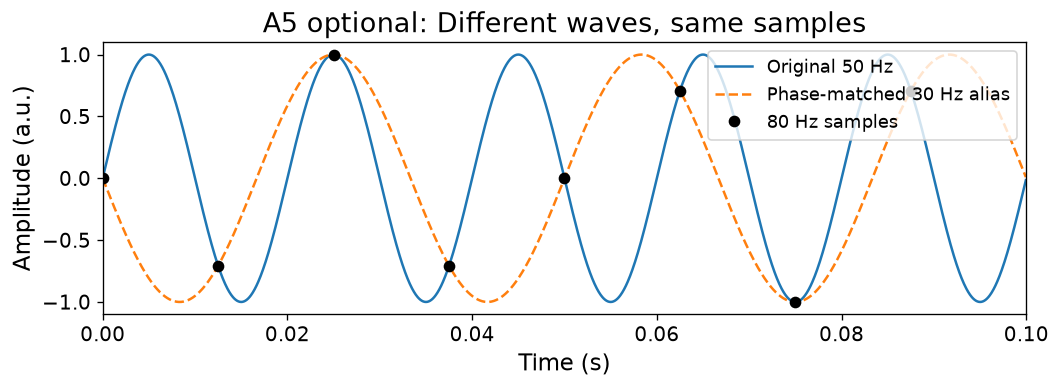

In [12]:
# Provided setup - run unchanged.
alias_time = np.arange(8) / 80
alias_samples = np.sin(2 * np.pi * 50 * alias_time)
alias_reference = -np.sin(2 * np.pi * 30 * dense_time)
fig, ax = plt.subplots()
ax.plot(dense_time, dense_wave, label='Original 50 Hz')
ax.plot(dense_time, alias_reference, '--', label='Phase-matched 30 Hz alias')
ax.plot(alias_time, alias_samples, 'ko', label='80 Hz samples')
ax.set(title='A5 optional: Different waves, same samples', xlabel='Time (s)',
       ylabel='Amplitude (a.u.)', xlim=(0, 0.1))
ax.legend(loc='upper right', fontsize=11)
fig.tight_layout()
plt.show()

**Self-check:** 50 Hz exceeds the 40 Hz Nyquist limit. These sample locations also match a phase-reversed 30 Hz sine. The samples alone cannot distinguish these two waves. Sampling exactly at twice a frequency does not guarantee faithful recovery for every phase.

<a id="module-b"></a>

# Module B - Time-Domain Features

Mean locates the center; sample SD measures variation about that center;
raw RMS measures magnitude relative to zero; peak-to-peak is maximum minus minimum.
`ddof=1` uses N-1 in the sample-variance denominator. `**2` squares each value;
`np.sqrt` takes a square root. Units remain a.u.

**Worked example:** for [-1, 0, 1], run the four supplied expressions below.
Then adapt them to the four-element array in B1.

**Start here:** run this module's setup, then any selected exercise. No earlier module or exercise answer is needed.

In [13]:
# Provided setup - run unchanged.
import numpy as np
import matplotlib.pyplot as plt
# Supplied display settings: readable figures, without changing the data.
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.figsize'] = (9, 3.4)
plt.rcParams['figure.dpi'] = 120

In [14]:
# Provided setup - run unchanged.
x1 = np.array([-2., -1., 1., 2.])
# x1 holds four synthetic amplitudes (a.u.); keep it unchanged for comparisons.
example = np.array([-1., 0., 1.])
print('Example mean:', np.mean(example), 'a.u.')
print('Example sample SD:', np.std(example, ddof=1), 'a.u.')
print('Example raw RMS:', np.sqrt(np.mean(example**2)), 'a.u.')
print('Example peak-to-peak:', np.ptp(example), 'a.u.')

Example mean: 0.0 a.u.
Example sample SD: 1.0 a.u.
Example raw RMS: 0.816496580927726 a.u.
Example peak-to-peak: 2.0 a.u.


<a id="b1"></a>

## B1 - [COMPLETE] Complete four scalar summaries

Complete the four short expressions for x1. Before running, identify its center and range from the values. Why can sample SD and RMS differ even when the mean is zero?

In [15]:
# All four summaries have the same amplitude unit as x1 (a.u.).
mean_value = np.mean(x1)
sd_value = np.std(x1, ddof=1)
rms_value = np.sqrt(np.mean(x1**2))
range_value = np.ptp(x1)

In [16]:
# Provided setup - run unchanged.
if mean_value is None or sd_value is None or rms_value is None or range_value is None:
    print('B1: complete all four expressions to display your scalar results.')
else:
    print('Mean / sample SD / RMS / peak-to-peak (a.u.):')
    print(np.round([mean_value, sd_value, rms_value, range_value], 4))

Mean / sample SD / RMS / peak-to-peak (a.u.):
[0.     1.8257 1.5811 4.    ]


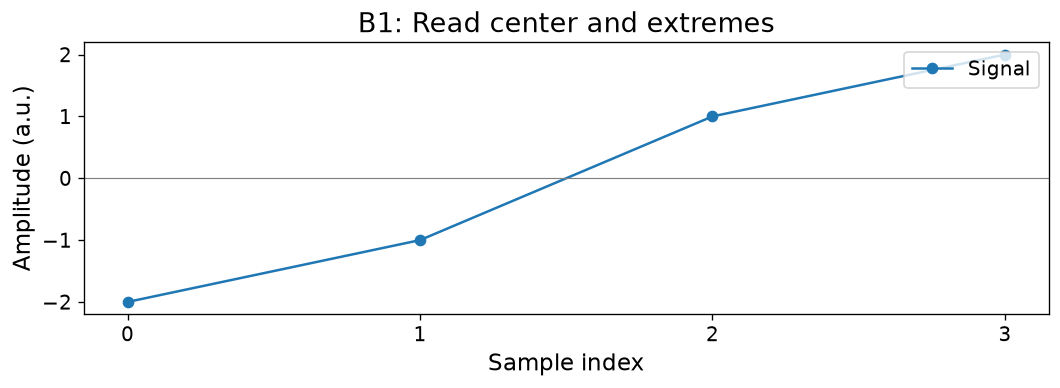

In [17]:
# Provided setup - run unchanged.
fig, ax = plt.subplots()
ax.plot(np.arange(len(x1)), x1, 'o-', label='Signal')
ax.axhline(0, color='gray', linewidth=0.7)
ax.set(title='B1: Read center and extremes', xlabel='Sample index', ylabel='Amplitude (a.u.)')
ax.set_xticks(np.arange(len(x1)))
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** Mean = 0, sample SD ≈ 1.8257, RMS ≈ 1.5811 and peak-to-peak = 4 a.u. SD uses N-1 while RMS averages squares using N. For N>1, RMS² = mean² + ((N-1)/N) × sample SD²; zero mean does not make these finite-sample quantities exactly equal.

<a id="b2"></a>

## B2 - [COMPARE] Zero mean versus an offset

Compare x1 with x2 = x1 + 10. Which features change, and which stay the same? Use the zero line and both outputs.

In [18]:
# Provided setup - run unchanged.
# x2 has a +10 a.u. offset; x1 remains unchanged.
x2 = x1 + 10
# Four summaries keep the signal's amplitude unit (a.u.).
print('Original x1')
print('Mean / sample SD / RMS / peak-to-peak (a.u.):')
print(np.round([np.mean(x1), np.std(x1, ddof=1),
                np.sqrt(np.mean(x1**2)), np.ptp(x1)], 4))
# Four summaries keep the signal's amplitude unit (a.u.).
print('Shifted x2')
print('Mean / sample SD / RMS / peak-to-peak (a.u.):')
print(np.round([np.mean(x2), np.std(x2, ddof=1),
                np.sqrt(np.mean(x2**2)), np.ptp(x2)], 4))

Original x1
Mean / sample SD / RMS / peak-to-peak (a.u.):
[0.     1.8257 1.5811 4.    ]
Shifted x2
Mean / sample SD / RMS / peak-to-peak (a.u.):
[10.      1.8257 10.1242  4.    ]


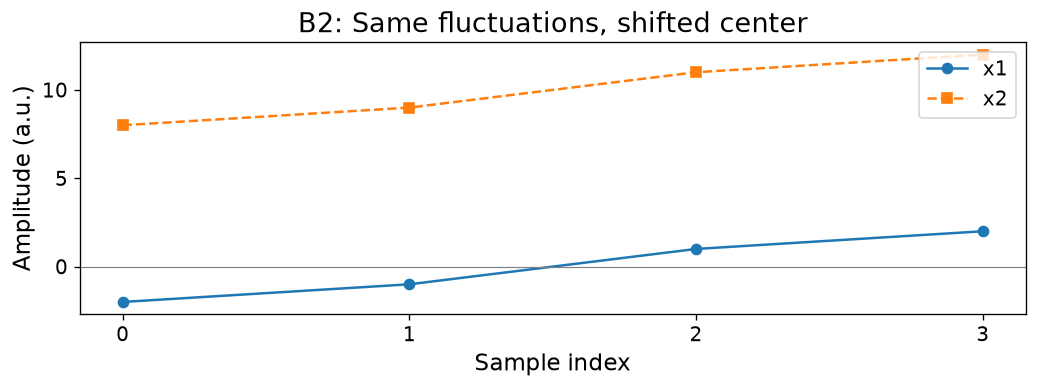

In [19]:
# Provided setup - run unchanged.
fig, ax = plt.subplots()
ax.plot(np.arange(len(x1)), x1, 'o-', label='x1')
ax.plot(np.arange(len(x2)), x2, 's--', label='x2')
ax.axhline(0, color='gray', linewidth=0.7)
ax.set(title='B2: Same fluctuations, shifted center', xlabel='Sample index', ylabel='Amplitude (a.u.)')
ax.set_xticks(np.arange(len(x1)))
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** Mean changes from 0 to 10 a.u. and raw RMS from about 1.5811 to 10.1242 a.u. Sample SD stays 1.8257 and peak-to-peak stays 4 a.u.; translation changes distance from zero but not variation about the center or the range.

<a id="b3"></a>

## B3 - [PREDICT] Predict a negative offset

Before running x3 = x1 - 3, predict whether sample SD and raw RMS change. Then check the supplied outputs. Does an arbitrary offset always increase RMS?

**Pause before running.** The expected prediction is discussed in the self-check below.

In [20]:
# Provided setup - run unchanged.
# Start from x1 every time; repeated execution never accumulates offsets.
x3 = x1 - 3
# Four summaries keep the signal's amplitude unit (a.u.).
print('Original x1')
print('Mean / sample SD / RMS / peak-to-peak (a.u.):')
print(np.round([np.mean(x1), np.std(x1, ddof=1),
                np.sqrt(np.mean(x1**2)), np.ptp(x1)], 4))
# Four summaries keep the signal's amplitude unit (a.u.).
print('Shifted x3')
print('Mean / sample SD / RMS / peak-to-peak (a.u.):')
print(np.round([np.mean(x3), np.std(x3, ddof=1),
                np.sqrt(np.mean(x3**2)), np.ptp(x3)], 4))

Original x1
Mean / sample SD / RMS / peak-to-peak (a.u.):
[0.     1.8257 1.5811 4.    ]
Shifted x3
Mean / sample SD / RMS / peak-to-peak (a.u.):
[-3.      1.8257  3.3912  4.    ]


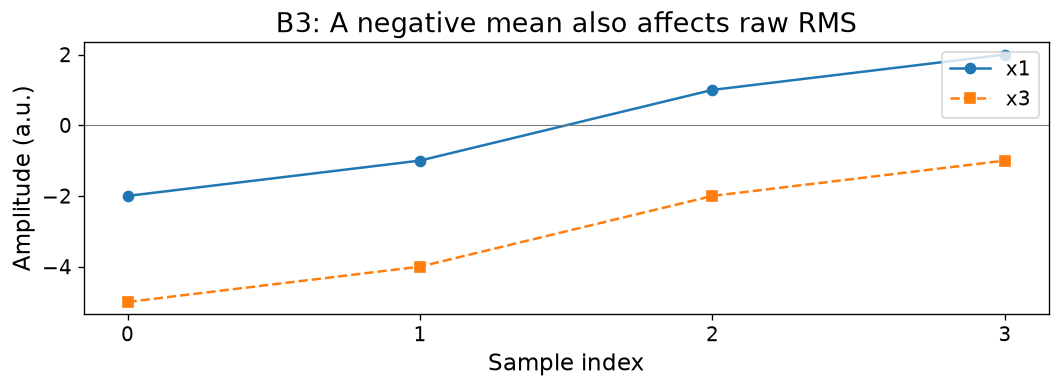

In [21]:
# Provided setup - run unchanged.
fig, ax = plt.subplots()
ax.plot(np.arange(len(x1)), x1, 'o-', label='x1')
ax.plot(np.arange(len(x3)), x3, 's--', label='x3')
ax.axhline(0, color='gray', linewidth=0.7)
ax.set(title='B3: A negative mean also affects raw RMS', xlabel='Sample index', ylabel='Amplitude (a.u.)')
ax.set_xticks(np.arange(len(x1)))
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** Prediction: SD stays the same and RMS increases for this zero-mean starting signal. Observed SD is about 1.8257 a.u.; RMS becomes 3.3912 a.u. The mean is -3. An offset can reduce RMS for a different starting mean if it moves the center toward zero.

<a id="b4"></a>

## B4 - [CHANGE] [DEBUG] Add one outlier and diagnose a range error

Run with the original final value 2, then replace it with 20. Compare the four features.
The suggested line below is wrong (not executed):

```python
peak_to_peak = np.max(x_outlier)
```

Complete a corrected range expression. Explain why the maximum alone is insufficient.

In [22]:
# last_value replaces one amplitude in a.u., not the whole array.
last_value = 20.0

In [23]:
# Provided setup - run unchanged.
x_outlier = x1.copy()
# Copy first: rerunning replaces one sample rather than accumulating changes.
x_outlier[-1] = last_value
# Four summaries keep the signal's amplitude unit (a.u.).
print('Original x1')
print('Mean / sample SD / RMS / peak-to-peak (a.u.):')
print(np.round([np.mean(x1), np.std(x1, ddof=1),
                np.sqrt(np.mean(x1**2)), np.ptp(x1)], 4))
# Four summaries keep the signal's amplitude unit (a.u.).
print('After replacing the final value')
print('Mean / sample SD / RMS / peak-to-peak (a.u.):')
print(np.round([np.mean(x_outlier), np.std(x_outlier, ddof=1),
                np.sqrt(np.mean(x_outlier**2)), np.ptp(x_outlier)], 4))

Original x1
Mean / sample SD / RMS / peak-to-peak (a.u.):
[0.     1.8257 1.5811 4.    ]
After replacing the final value
Mean / sample SD / RMS / peak-to-peak (a.u.):
[ 4.5    10.4083 10.0747 22.    ]


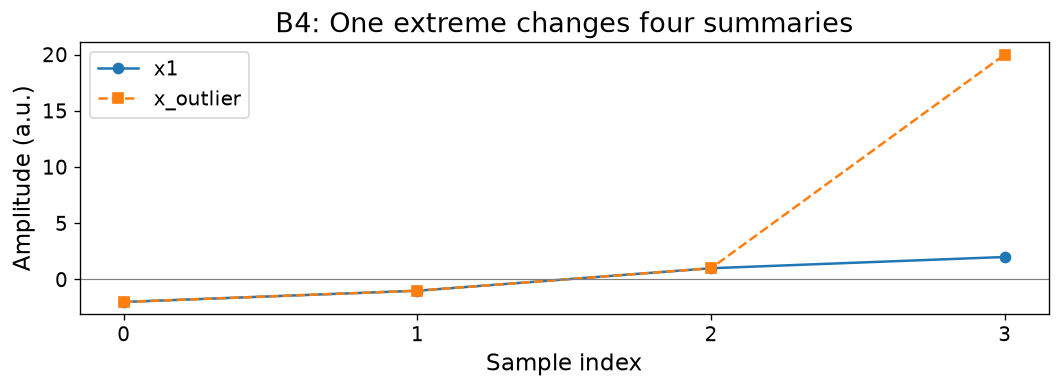

In [24]:
# Provided setup - run unchanged.
fig, ax = plt.subplots()
ax.plot(np.arange(len(x1)), x1, 'o-', label='x1')
ax.plot(np.arange(len(x_outlier)), x_outlier, 's--', label='x_outlier')
ax.axhline(0, color='gray', linewidth=0.7)
ax.set(title='B4: One extreme changes four summaries', xlabel='Sample index', ylabel='Amplitude (a.u.)')
ax.set_xticks(np.arange(len(x1)))
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

In [25]:
# Range includes both extremes, in a.u.
corrected_range = np.max(x_outlier) - np.min(x_outlier)

In [26]:
# Provided setup - run unchanged.
if corrected_range is None:
    print('B4: enter the corrected range expression.')
else:
    print('Corrected peak-to-peak:', corrected_range, 'a.u.')

Corrected peak-to-peak: 22.0 a.u.


**Self-check - one possible answer.** With final value 20, mean = 4.5, sample SD ≈ 10.4083, RMS ≈ 10.0747 and peak-to-peak = 22 a.u. All four increase here. The incorrect maximum is only 20; the range is 20 - (-2) = 22. Peak-to-peak is directly controlled by the two extremes.

<a id="b5"></a>

## B5 - [COMPARE] Equal scalars, different waveform order

Compare the two sequences below. Check all four summaries, not just RMS. Can these scalars tell you how the signal changes in time?

In [27]:
# Provided setup - run unchanged.
alternating = np.array([-1., 1., -1., 1., -1., 1., -1., 1.])
grouped = np.array([-1., -1., -1., -1., 1., 1., 1., 1.])
# Same values, different order; sample index is used because no rate is assigned.
# Four summaries keep the signal's amplitude unit (a.u.).
print('Alternating')
print('Mean / sample SD / RMS / peak-to-peak (a.u.):')
print(np.round([np.mean(alternating), np.std(alternating, ddof=1),
                np.sqrt(np.mean(alternating**2)), np.ptp(alternating)], 4))
# Four summaries keep the signal's amplitude unit (a.u.).
print('Grouped')
print('Mean / sample SD / RMS / peak-to-peak (a.u.):')
print(np.round([np.mean(grouped), np.std(grouped, ddof=1),
                np.sqrt(np.mean(grouped**2)), np.ptp(grouped)], 4))

Alternating
Mean / sample SD / RMS / peak-to-peak (a.u.):
[0.    1.069 1.    2.   ]
Grouped
Mean / sample SD / RMS / peak-to-peak (a.u.):
[0.    1.069 1.    2.   ]


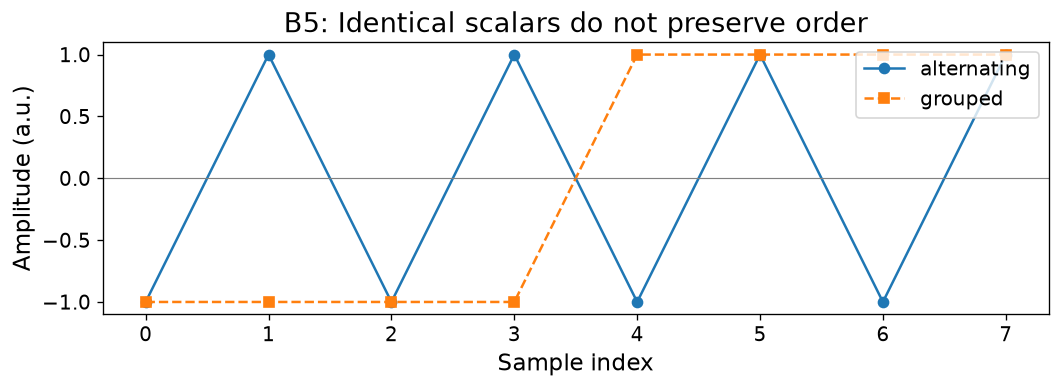

In [28]:
# Provided setup - run unchanged.
fig, ax = plt.subplots()
ax.plot(np.arange(len(alternating)), alternating, 'o-', label='alternating')
ax.plot(np.arange(len(grouped)), grouped, 's--', label='grouped')
ax.axhline(0, color='gray', linewidth=0.7)
ax.set(title='B5: Identical scalars do not preserve order', xlabel='Sample index', ylabel='Amplitude (a.u.)')
ax.set_xticks(np.arange(len(alternating)))
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** Both have mean 0, sample SD ≈ 1.0690, RMS 1 and peak-to-peak 2 a.u. One alternates every sample; the other changes sign once. These summaries ignore temporal order, so even all four together cannot fully describe the waveform.

### B5 optional challenge: equal RMS, different crest factor

Run the supplied comparison (about 5 extra minutes). Crest factor is max(abs(x))/RMS, a dimensionless ratio. Neither array has zero RMS.

RMS values (a.u.): 1.0 1.0
Crest factors: 1.0 2.8284271247461903


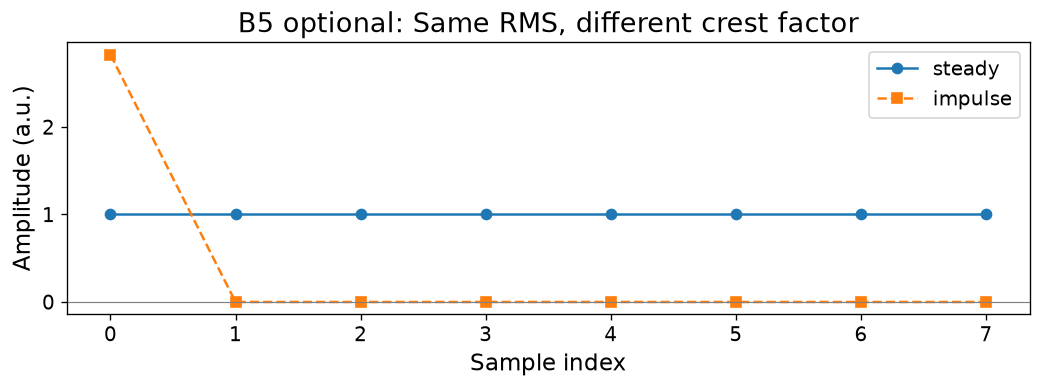

In [29]:
# Provided setup - run unchanged.
steady = np.ones(8)
impulse = np.array([np.sqrt(8), 0., 0., 0., 0., 0., 0., 0.])
# The same RMS can accompany very different extremes.
steady_rms = np.sqrt(np.mean(steady**2))
impulse_rms = np.sqrt(np.mean(impulse**2))
print('RMS values (a.u.):', steady_rms, impulse_rms)
print('Crest factors:', np.max(np.abs(steady))/steady_rms,
      np.max(np.abs(impulse))/impulse_rms)
fig, ax = plt.subplots()
ax.plot(np.arange(len(steady)), steady, 'o-', label='steady')
ax.plot(np.arange(len(impulse)), impulse, 's--', label='impulse')
ax.axhline(0, color='gray', linewidth=0.7)
ax.set(title='B5 optional: Same RMS, different crest factor', xlabel='Sample index', ylabel='Amplitude (a.u.)')
ax.set_xticks(np.arange(len(steady)))
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

**Self-check:** both RMS values are 1 a.u.; crest factors are 1 and sqrt(8) ≈ 2.8284. A concentrated extreme can be hidden by RMS alone. These are exploratory descriptors, not validated fault thresholds.

<a id="module-c"></a>

# Module C - FFT and Frequency Components

A sine wave's frequency is its cycles per second; its amplitude controls height.
An FFT magnitude plot shows frequency content over the complete record.
Predict locations before running; supplied FFT code handles scaling for you.

**Reading guide:** horizontal = frequency (Hz); vertical = one-sided amplitude
(a.u.). A periodic Hann window reduces edge leakage but broadens a component
around its center. The plots retain physical amplitude scaling, not per-plot
normalization. No FFT implementation is requested.

**Start here:** run this module's setup, then any selected exercise. No earlier module or exercise answer is needed.

In [30]:
# Provided setup - run unchanged.
import numpy as np
import matplotlib.pyplot as plt
# Supplied display settings: readable figures, without changing the data.
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.figsize'] = (9, 3.4)
plt.rcParams['figure.dpi'] = 120

In [31]:
# Provided setup - run unchanged.
from scipy.fft import rfft, rfftfreq
from scipy.signal.windows import hann
fs = 1000
# Sampling rate in Hz; it sets the time interval and the 500 Hz Nyquist limit.
N = 1000
# N samples span a nominal 1 second; endpoint 1 s is excluded.
time_s = np.arange(N) / fs
frequency_hz = 50
# The first sine completes 50 cycles each second; amplitude is 1 a.u.
tone50 = np.sin(2 * np.pi * frequency_hz * time_s)
print('Nominal duration (s):', N/fs, '| Frequency-bin spacing (Hz):', fs/N)

Nominal duration (s): 1.0 | Frequency-bin spacing (Hz): 1.0


<a id="c1"></a>

## C1 - [PREDICT] Predict one peak

Before running, predict the main peak for the 50 Hz sine. Compare a short waveform view with its whole-record FFT. Read both axis units.

**Pause before running.** The expected prediction is discussed in the self-check below.

In [32]:
# Provided setup - run unchanged.
# C1_centered holds oscillations in a.u.; remove only the full-record mean.
C1_centered = tone50 - np.mean(tone50)
# The periodic Hann weights reduce spectral leakage at the record edges.
C1_window = hann(len(tone50), sym=False)
C1_coefficients = rfft(C1_centered * C1_window)
# C1_hz gives cycles per second for each coefficient.
C1_hz = rfftfreq(len(tone50), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
C1_magnitude = np.abs(C1_coefficients) / np.sum(C1_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
C1_magnitude[1:-1] *= 2

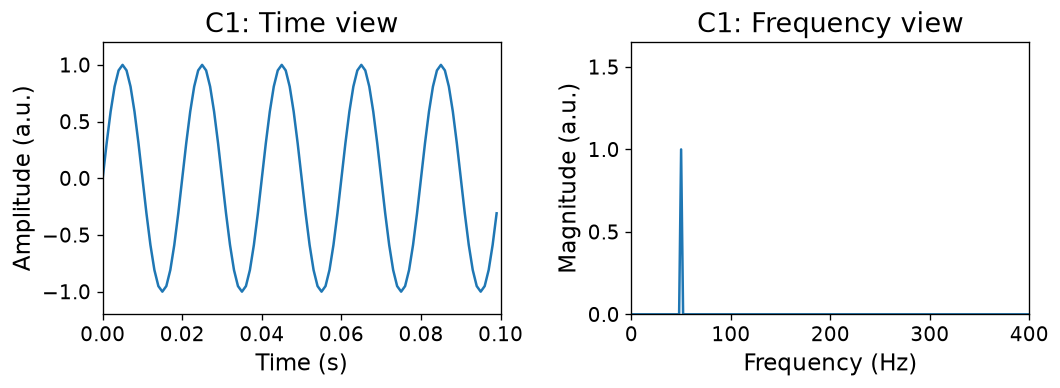

In [33]:
# Provided setup - run unchanged.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
ax1.plot(time_s[:100], tone50[:100])
ax1.set(title='C1: Time view', xlabel='Time (s)', ylabel='Amplitude (a.u.)',
        xlim=(0, 0.1), ylim=(-1.2, 1.2))
ax2.plot(C1_hz, C1_magnitude)
ax2.set(title='C1: Frequency view', xlabel='Frequency (Hz)', ylabel='Magnitude (a.u.)',
        xlim=(0, 400), ylim=(0, 1.65))
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** Prediction: a main peak at 50 Hz. The observed center-bin magnitude is 1 a.u. The waveform shows cycles in time; the FFT locates frequency content. The Hann window creates neighboring-bin structure, not another physical tone.

<a id="c2"></a>

## C2 - [PREDICT] [COMPARE] Predict two peaks, then add noise

Predict the peaks for a 1 a.u. 50 Hz component plus a 0.5 a.u. 120 Hz component. Compare one versus two tones. Then run the supplied noise example: can you still identify the intended frequencies?

**Pause before running.** The expected prediction is discussed in the self-check below.

In [34]:
# Provided setup - run unchanged.
# The second component has amplitude 0.5 a.u. and frequency 120 Hz.
tone120 = 0.5 * np.sin(2 * np.pi * 120 * time_s)
two_tone = tone50 + tone120
# Recreate seed 42 here so repeated execution produces the same noise.
rng = np.random.default_rng(42)
noise = 0.3 * rng.standard_normal(N)
# noise is a synthetic amplitude perturbation (a.u.), not a new measured signal.
noisy_tone = two_tone + noise

In [35]:
# Provided setup - run unchanged.
# C2_single_centered holds oscillations in a.u.; remove only the full-record mean.
C2_single_centered = tone50 - np.mean(tone50)
# The periodic Hann weights reduce spectral leakage at the record edges.
C2_single_window = hann(len(tone50), sym=False)
C2_single_coefficients = rfft(C2_single_centered * C2_single_window)
# C2_single_hz gives cycles per second for each coefficient.
C2_single_hz = rfftfreq(len(tone50), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
C2_single_magnitude = np.abs(C2_single_coefficients) / np.sum(C2_single_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
C2_single_magnitude[1:-1] *= 2

In [36]:
# Provided setup - run unchanged.
# C2_clean_centered holds oscillations in a.u.; remove only the full-record mean.
C2_clean_centered = two_tone - np.mean(two_tone)
# The periodic Hann weights reduce spectral leakage at the record edges.
C2_clean_window = hann(len(two_tone), sym=False)
C2_clean_coefficients = rfft(C2_clean_centered * C2_clean_window)
# C2_clean_hz gives cycles per second for each coefficient.
C2_clean_hz = rfftfreq(len(two_tone), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
C2_clean_magnitude = np.abs(C2_clean_coefficients) / np.sum(C2_clean_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
C2_clean_magnitude[1:-1] *= 2

In [37]:
# Provided setup - run unchanged.
# C2_noisy_centered holds oscillations in a.u.; remove only the full-record mean.
C2_noisy_centered = noisy_tone - np.mean(noisy_tone)
# The periodic Hann weights reduce spectral leakage at the record edges.
C2_noisy_window = hann(len(noisy_tone), sym=False)
C2_noisy_coefficients = rfft(C2_noisy_centered * C2_noisy_window)
# C2_noisy_hz gives cycles per second for each coefficient.
C2_noisy_hz = rfftfreq(len(noisy_tone), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
C2_noisy_magnitude = np.abs(C2_noisy_coefficients) / np.sum(C2_noisy_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
C2_noisy_magnitude[1:-1] *= 2

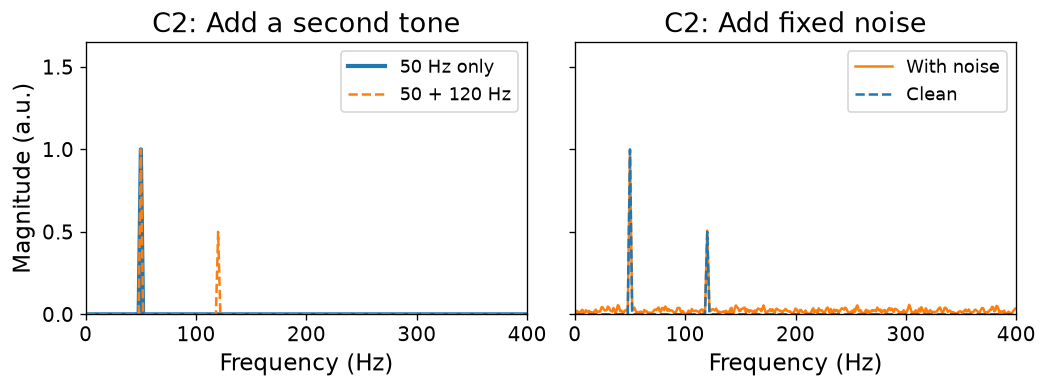

In [38]:
# Provided setup - run unchanged.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4), sharex=True, sharey=True)
ax1.plot(C2_single_hz, C2_single_magnitude, label='50 Hz only', linewidth=2.5)
ax1.plot(C2_clean_hz, C2_clean_magnitude, '--', label='50 + 120 Hz')
ax2.plot(C2_noisy_hz, C2_noisy_magnitude, color='tab:orange', label='With noise')
ax2.plot(C2_clean_hz, C2_clean_magnitude, '--', color='tab:blue', label='Clean')
ax1.set(title='C2: Add a second tone', xlabel='Frequency (Hz)', ylabel='Magnitude (a.u.)',
        xlim=(0, 400), ylim=(0, 1.65))
ax2.set(title='C2: Add fixed noise', xlabel='Frequency (Hz)', xlim=(0, 400))
ax1.legend(loc='upper right', fontsize=11)
ax2.legend(loc='upper right', fontsize=11)
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** Prediction: peaks at 50 and 120 Hz, with heights 1 and 0.5 a.u. in the clean signal. The noisy version retains recognizable peaks near these frequencies above a background. Noise perturbs heights; it does not change the frequencies used to construct the two tones. Both panels use the same scale.

<a id="c3"></a>

## C3 - [CHANGE] Change amplitude only

Run the baseline second-component amplitude 0.5, then change it to 1.5 a.u. Predict which changes: peak location or height. The 50 Hz component remains at amplitude 1.

In [39]:
# Increase the second component's amplitude, not its frequency.
second_amplitude = 1.5

In [40]:
# Provided setup - run unchanged.
# Reconstruct both signals; C2's variables and answers are not needed.
reference_signal = tone50 + 0.5 * np.sin(2 * np.pi * 120 * time_s)
changed_signal = tone50 + second_amplitude * np.sin(2 * np.pi * 120 * time_s)

In [41]:
# Provided setup - run unchanged.
# C3_ref_centered holds oscillations in a.u.; remove only the full-record mean.
C3_ref_centered = reference_signal - np.mean(reference_signal)
# The periodic Hann weights reduce spectral leakage at the record edges.
C3_ref_window = hann(len(reference_signal), sym=False)
C3_ref_coefficients = rfft(C3_ref_centered * C3_ref_window)
# C3_ref_hz gives cycles per second for each coefficient.
C3_ref_hz = rfftfreq(len(reference_signal), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
C3_ref_magnitude = np.abs(C3_ref_coefficients) / np.sum(C3_ref_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
C3_ref_magnitude[1:-1] *= 2

In [42]:
# Provided setup - run unchanged.
# C3_new_centered holds oscillations in a.u.; remove only the full-record mean.
C3_new_centered = changed_signal - np.mean(changed_signal)
# The periodic Hann weights reduce spectral leakage at the record edges.
C3_new_window = hann(len(changed_signal), sym=False)
C3_new_coefficients = rfft(C3_new_centered * C3_new_window)
# C3_new_hz gives cycles per second for each coefficient.
C3_new_hz = rfftfreq(len(changed_signal), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
C3_new_magnitude = np.abs(C3_new_coefficients) / np.sum(C3_new_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
C3_new_magnitude[1:-1] *= 2

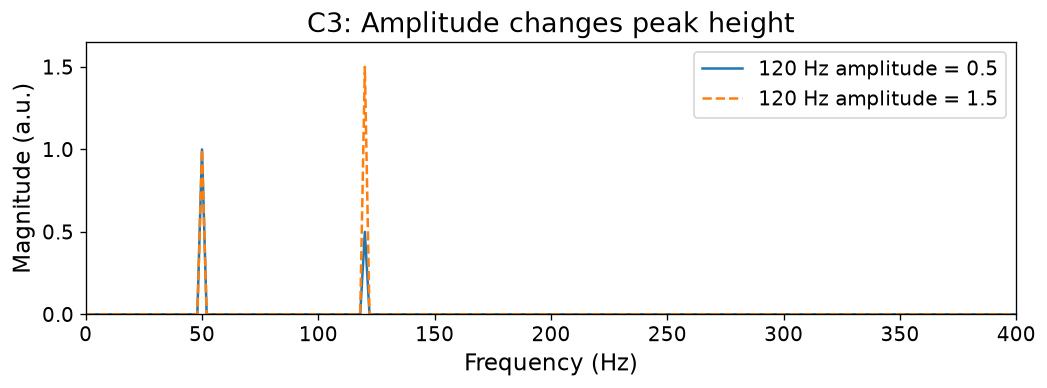

In [43]:
# Provided setup - run unchanged.
fig, ax = plt.subplots()
ax.plot(C3_ref_hz, C3_ref_magnitude, label='120 Hz amplitude = 0.5')
ax.plot(C3_new_hz, C3_new_magnitude, '--', label=f'120 Hz amplitude = {second_amplitude}')
ax.set(title='C3: Amplitude changes peak height', xlabel='Frequency (Hz)',
       ylabel='Magnitude (a.u.)', xlim=(0, 400), ylim=(0, 1.65))
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** Changing 0.5 to 1.5 makes the 120 Hz peak three times as high. Its location stays 120 Hz; the 50 Hz peak remains at 1 a.u. The shared magnitude scale makes the amplitude change visible.

<a id="c4"></a>

## C4 - [CHANGE] Change frequency only

Starting from baseline amplitudes (1 and 0.5 a.u.), change the second frequency from 120 to 200 Hz. Which peak moves? Do not inherit the amplitude change from C3.

In [44]:
# Move only the second component in frequency.
second_frequency_hz = 200

In [45]:
# Provided setup - run unchanged.
reference_signal = tone50 + 0.5 * np.sin(2 * np.pi * 120 * time_s)
# Explicit amplitude 0.5 restores the baseline regardless of C3.
changed_signal = tone50 + 0.5 * np.sin(2 * np.pi * second_frequency_hz * time_s)

In [46]:
# Provided setup - run unchanged.
# C4_ref_centered holds oscillations in a.u.; remove only the full-record mean.
C4_ref_centered = reference_signal - np.mean(reference_signal)
# The periodic Hann weights reduce spectral leakage at the record edges.
C4_ref_window = hann(len(reference_signal), sym=False)
C4_ref_coefficients = rfft(C4_ref_centered * C4_ref_window)
# C4_ref_hz gives cycles per second for each coefficient.
C4_ref_hz = rfftfreq(len(reference_signal), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
C4_ref_magnitude = np.abs(C4_ref_coefficients) / np.sum(C4_ref_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
C4_ref_magnitude[1:-1] *= 2

In [47]:
# Provided setup - run unchanged.
# C4_new_centered holds oscillations in a.u.; remove only the full-record mean.
C4_new_centered = changed_signal - np.mean(changed_signal)
# The periodic Hann weights reduce spectral leakage at the record edges.
C4_new_window = hann(len(changed_signal), sym=False)
C4_new_coefficients = rfft(C4_new_centered * C4_new_window)
# C4_new_hz gives cycles per second for each coefficient.
C4_new_hz = rfftfreq(len(changed_signal), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
C4_new_magnitude = np.abs(C4_new_coefficients) / np.sum(C4_new_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
C4_new_magnitude[1:-1] *= 2

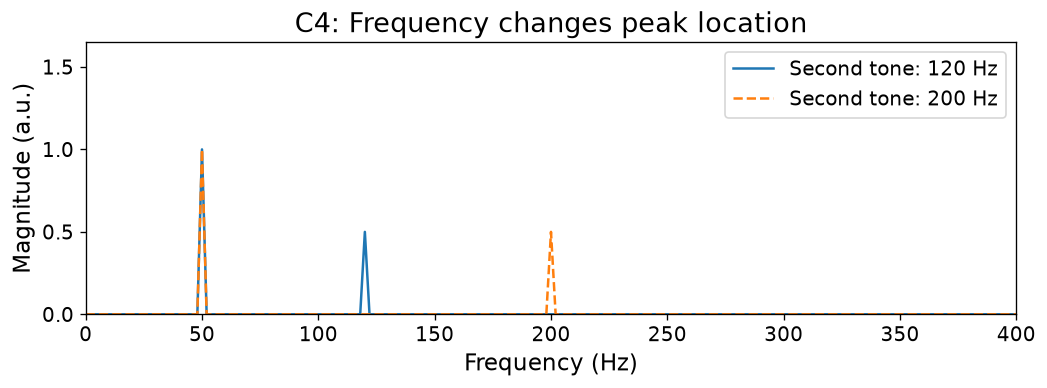

In [48]:
# Provided setup - run unchanged.
fig, ax = plt.subplots()
ax.plot(C4_ref_hz, C4_ref_magnitude, label='Second tone: 120 Hz')
ax.plot(C4_new_hz, C4_new_magnitude, '--', label=f'Second tone: {second_frequency_hz} Hz')
ax.set(title='C4: Frequency changes peak location', xlabel='Frequency (Hz)',
       ylabel='Magnitude (a.u.)', xlim=(0, 400), ylim=(0, 1.65))
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** The second peak moves from 120 to 200 Hz while staying at 0.5 a.u. The first peak stays at 50 Hz and 1 a.u. C4 explicitly resets the amplitude, isolating a frequency change.

<a id="c5"></a>

## C5 - [DEBUG] Repair the FFT axis label

This label is intentionally wrong and is not executed:

```python
ax.set_xlabel("Time (s)")
```

Enter the corrected label as a quoted string. The supplied plot applies it with
`ax.set_xlabel(axis_label)`. Explain why the FFT's horizontal axis is not time.

In [49]:
axis_label = "Frequency (Hz)"
# FFT bins represent cycles per second, not time samples.

In [50]:
# Provided setup - run unchanged.
# C5_centered holds oscillations in a.u.; remove only the full-record mean.
C5_centered = tone50 - np.mean(tone50)
# The periodic Hann weights reduce spectral leakage at the record edges.
C5_window = hann(len(tone50), sym=False)
C5_coefficients = rfft(C5_centered * C5_window)
# C5_hz gives cycles per second for each coefficient.
C5_hz = rfftfreq(len(tone50), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
C5_magnitude = np.abs(C5_coefficients) / np.sum(C5_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
C5_magnitude[1:-1] *= 2

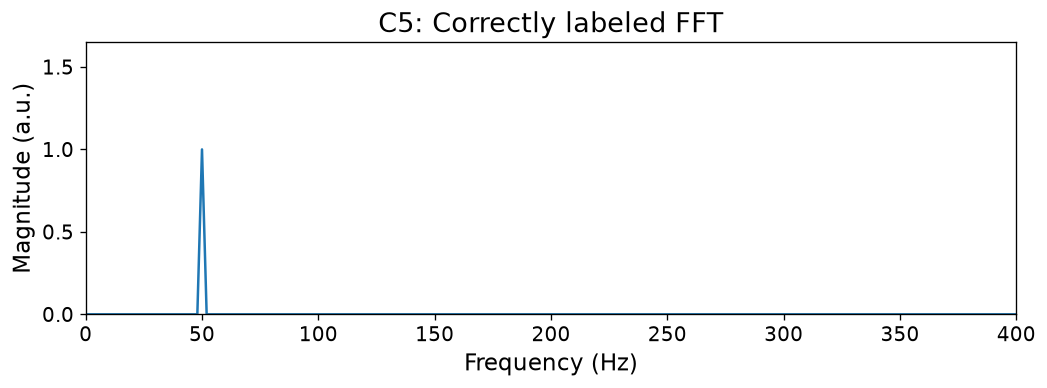

In [51]:
# Provided setup - run unchanged.
if axis_label is None:
    print('C5: enter the corrected axis label to display the spectrum.')
else:
    fig, ax = plt.subplots()
    ax.plot(C5_hz, C5_magnitude)
    ax.set_xlabel(axis_label)
    ax.set(title='C5: Correctly labeled FFT', ylabel='Magnitude (a.u.)',
           xlim=(0, 400), ylim=(0, 1.65))
    fig.tight_layout()
    plt.show()

**Self-check - one possible answer.** The corrected line is `ax.set_xlabel("Frequency (Hz)")`. Each horizontal coordinate is the frequency of an FFT bin, assigned by `rfftfreq`; labeling it seconds would misidentify what the plot represents.

<a id="module-d"></a>

# Module D - FFT vs STFT and Time Localization

A whole-record magnitude spectrum summarizes which frequencies occur. A
spectrogram shows how short-window frequency content changes with time.
Here the first second contains 50 Hz; the second contains 150 Hz.

**Read a spectrogram:** left-to-right = window-center time (s), bottom-to-top =
frequency (Hz), color = power spectral density (PSD). The display uses dB relative
to 1 a.u.²/Hz; it is STFT-based power, not the complex STFT itself.

All spectral code is supplied. Default window: 128 samples (128 ms); overlap:
96 samples; hop: 32 samples (32 ms). Incomplete edge windows are omitted, so blank
edge regions do not mean silence. A change can spread across neighboring windows.

**Start here:** run this module's setup, then any selected exercise. No earlier module or exercise answer is needed.

In [52]:
# Provided setup - run unchanged.
import numpy as np
import matplotlib.pyplot as plt
# Supplied display settings: readable figures, without changing the data.
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.figsize'] = (9, 3.4)
plt.rcParams['figure.dpi'] = 120

In [53]:
# Provided setup - run unchanged.
from scipy.fft import rfft, rfftfreq
from scipy.signal.windows import hann
from scipy.signal import spectrogram
fs = 1000
# Sampling rate in Hz; each sample is 0.001 s apart.
N = 2000
# N samples cover 2 seconds nominally; time_s excludes the endpoint 2 s.
time_s = np.arange(N) / fs
# baseline holds 2 seconds of synthetic amplitude (a.u.).
baseline = np.sin(2 * np.pi * 50 * time_s)
# The second half starts at sample 1000, corresponding to 1 second.
baseline[1000:] = np.sin(2 * np.pi * 150 * time_s[1000:])
print('Nominal duration:', N/fs, 's | Switch time:', 1000/fs, 's')

Nominal duration: 2.0 s | Switch time: 1.0 s


<a id="d1"></a>

## D1 - [PREDICT] Predict a whole-record FFT

Predict which frequencies appear when the first half is 50 Hz and the second half is 150 Hz. Run the waveform and magnitude spectrum. Can the magnitude plot tell you which occurred first?

**Pause before running.** The expected prediction is discussed in the self-check below.

In [54]:
# Provided setup - run unchanged.
# D1_centered holds oscillations in a.u.; remove only the full-record mean.
D1_centered = baseline - np.mean(baseline)
# The periodic Hann weights reduce spectral leakage at the record edges.
D1_window = hann(len(baseline), sym=False)
D1_coefficients = rfft(D1_centered * D1_window)
# D1_hz gives cycles per second for each coefficient.
D1_hz = rfftfreq(len(baseline), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
D1_magnitude = np.abs(D1_coefficients) / np.sum(D1_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
D1_magnitude[1:-1] *= 2

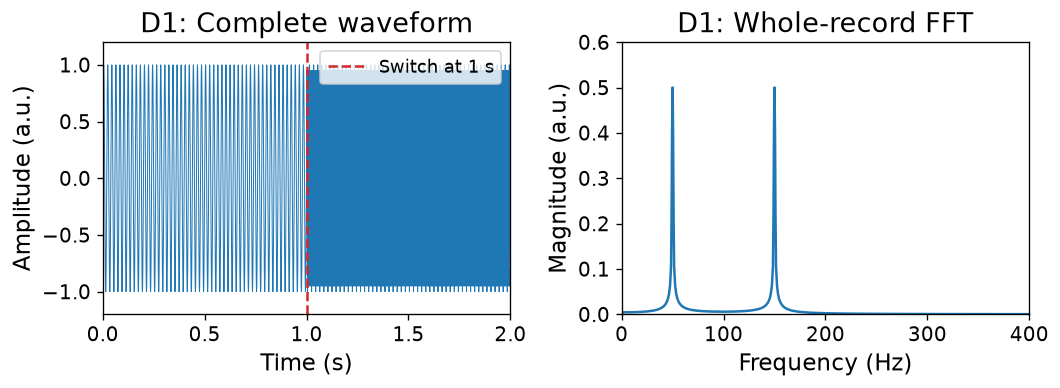

In [55]:
# Provided setup - run unchanged.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
ax1.plot(time_s, baseline, linewidth=0.6)
ax1.axvline(1, color='tab:red', linestyle='--', label='Switch at 1 s')
ax1.set(title='D1: Complete waveform', xlabel='Time (s)', ylabel='Amplitude (a.u.)',
        xlim=(0, 2), ylim=(-1.2, 1.2))
ax1.legend(loc='upper right', fontsize=11)
ax2.plot(D1_hz, D1_magnitude)
ax2.set(title='D1: Whole-record FFT', xlabel='Frequency (Hz)', ylabel='Magnitude (a.u.)',
        xlim=(0, 400), ylim=(0, 0.6))
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** Prediction: substantial content near 50 and 150 Hz. Both appear, with spectral spread from the finite record and switching. The displayed magnitude does not label which tone occurred first. This statement concerns the magnitude plot, not information loss in the full complex FFT.

<a id="d2"></a>

## D2 - [INTERPRET] Read when each frequency occurs

Run the supplied spectrogram. Approximately when does the 50 Hz band occur, and when does the 150 Hz band occur? Why is the transition not a perfectly sharp vertical boundary?

In [56]:
# Provided setup - run unchanged.
# One window contains 128 samples; the hop is 32 samples.
# Global centering retains within-record changes; no per-frame detrending.
D2_centered = baseline - np.mean(baseline)
# SciPy returns Hz, window-center time (s), and PSD (a.u.²/Hz).
D2_hz, D2_time, D2_psd = spectrogram(
    D2_centered, fs=fs, window='hann', nperseg=128, noverlap=96,
    nfft=128, detrend=False, scaling='density', mode='psd')
# The floor avoids log(0); dB is relative to 1 a.u.²/Hz, not each plot's maximum.
D2_db = 10 * np.log10(np.maximum(D2_psd, 1e-20))

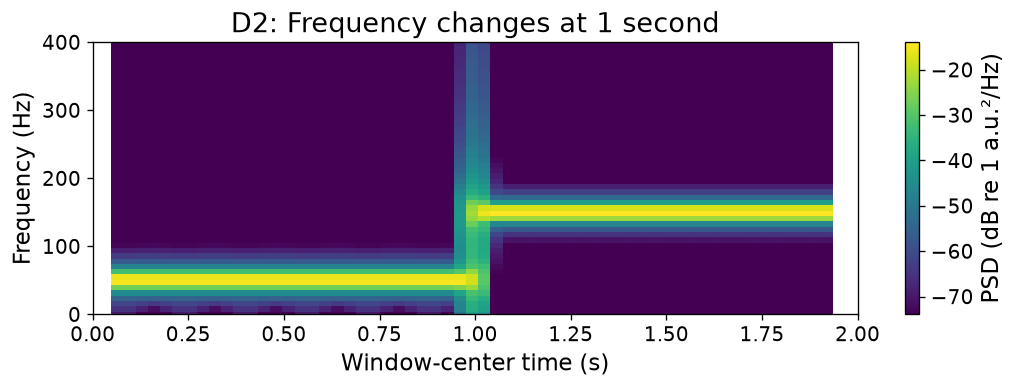

In [57]:
# Provided setup - run unchanged.
# A fixed 60 dB display span makes weak structure visible.
color_max = np.max(D2_db)
fig, ax = plt.subplots()
image = ax.pcolormesh(D2_time, D2_hz, D2_db, shading='auto',
                      vmin=color_max-60, vmax=color_max, rasterized=True)
ax.set(title='D2: Frequency changes at 1 second', xlabel='Window-center time (s)', ylabel='Frequency (Hz)',
       xlim=(0, 2), ylim=(0, 400))
fig.colorbar(image, ax=ax, label='PSD (dB re 1 a.u.²/Hz)')
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** The 50 Hz band occurs mainly before 1 s and the 150 Hz band mainly after 1 s. Windows straddling the switch contain both, so the transition spreads in time. Window-center times locate the analysis, not instantaneous measurements.

<a id="d3"></a>

## D3 - [CHANGE] [DEBUG] Swap order and debug an interpretation

Change the first frequency to 150 Hz and the second to 50 Hz. Compare both
spectrograms and the whole-record magnitude overlay. Correct this statement:
**“Similar FFT magnitude means the same event order.”**

In [58]:
# Swap order while keeping both frequencies and the 1-second switch.
first_frequency_hz = 150
second_frequency_hz = 50

In [59]:
# Provided setup - run unchanged.
# swapped holds 2 seconds of synthetic amplitude (a.u.).
swapped = np.sin(2 * np.pi * first_frequency_hz * time_s)
# The second half starts at sample 1000, corresponding to 1 second.
swapped[1000:] = np.sin(2 * np.pi * second_frequency_hz * time_s[1000:])

In [60]:
# Provided setup - run unchanged.
# D3_ref_centered holds oscillations in a.u.; remove only the full-record mean.
D3_ref_centered = baseline - np.mean(baseline)
# The periodic Hann weights reduce spectral leakage at the record edges.
D3_ref_window = hann(len(baseline), sym=False)
D3_ref_coefficients = rfft(D3_ref_centered * D3_ref_window)
# D3_ref_hz gives cycles per second for each coefficient.
D3_ref_hz = rfftfreq(len(baseline), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
D3_ref_magnitude = np.abs(D3_ref_coefficients) / np.sum(D3_ref_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
D3_ref_magnitude[1:-1] *= 2

In [61]:
# Provided setup - run unchanged.
# D3_swap_centered holds oscillations in a.u.; remove only the full-record mean.
D3_swap_centered = swapped - np.mean(swapped)
# The periodic Hann weights reduce spectral leakage at the record edges.
D3_swap_window = hann(len(swapped), sym=False)
D3_swap_coefficients = rfft(D3_swap_centered * D3_swap_window)
# D3_swap_hz gives cycles per second for each coefficient.
D3_swap_hz = rfftfreq(len(swapped), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
D3_swap_magnitude = np.abs(D3_swap_coefficients) / np.sum(D3_swap_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
D3_swap_magnitude[1:-1] *= 2

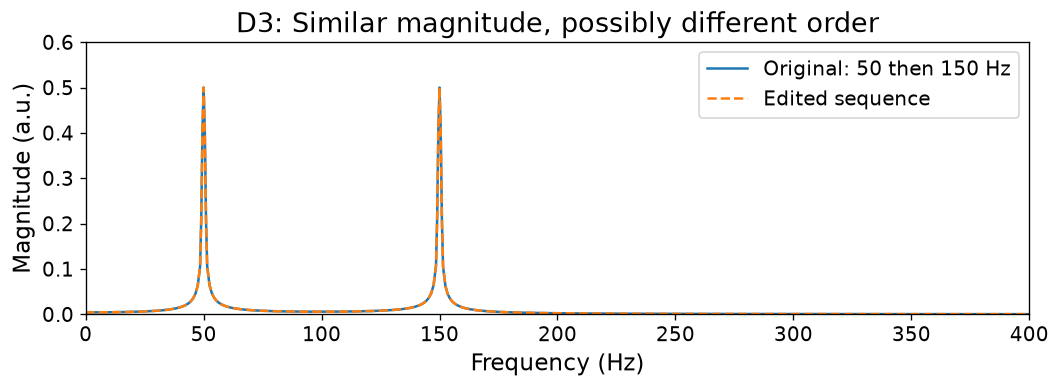

In [62]:
# Provided setup - run unchanged.
fig, ax = plt.subplots()
ax.plot(D3_ref_hz, D3_ref_magnitude, label='Original: 50 then 150 Hz')
ax.plot(D3_swap_hz, D3_swap_magnitude, '--', label='Edited sequence')
ax.set(title='D3: Similar magnitude, possibly different order', xlabel='Frequency (Hz)',
       ylabel='Magnitude (a.u.)', xlim=(0, 400), ylim=(0, 0.6))
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

In [63]:
# Provided setup - run unchanged.
# One window contains 128 samples; the hop is 32 samples.
# Global centering retains within-record changes; no per-frame detrending.
D3_before_centered = baseline - np.mean(baseline)
# SciPy returns Hz, window-center time (s), and PSD (a.u.²/Hz).
D3_before_hz, D3_before_time, D3_before_psd = spectrogram(
    D3_before_centered, fs=fs, window='hann', nperseg=128, noverlap=96,
    nfft=128, detrend=False, scaling='density', mode='psd')
# The floor avoids log(0); dB is relative to 1 a.u.²/Hz, not each plot's maximum.
D3_before_db = 10 * np.log10(np.maximum(D3_before_psd, 1e-20))

In [64]:
# Provided setup - run unchanged.
# One window contains 128 samples; the hop is 32 samples.
# Global centering retains within-record changes; no per-frame detrending.
D3_after_centered = swapped - np.mean(swapped)
# SciPy returns Hz, window-center time (s), and PSD (a.u.²/Hz).
D3_after_hz, D3_after_time, D3_after_psd = spectrogram(
    D3_after_centered, fs=fs, window='hann', nperseg=128, noverlap=96,
    nfft=128, detrend=False, scaling='density', mode='psd')
# The floor avoids log(0); dB is relative to 1 a.u.²/Hz, not each plot's maximum.
D3_after_db = 10 * np.log10(np.maximum(D3_after_psd, 1e-20))

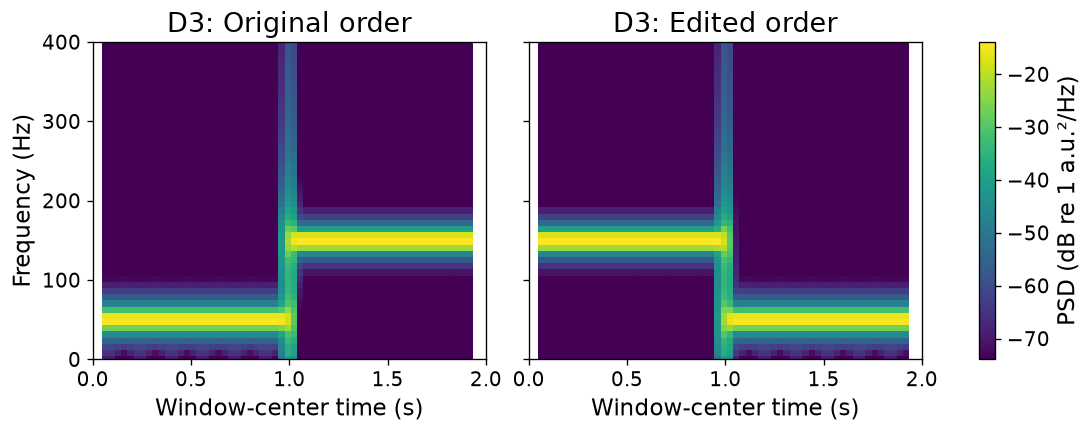

In [65]:
# Provided setup - run unchanged.
# Both panels use ONE color range; neither is normalized independently.
color_max = max(np.max(D3_before_db), np.max(D3_after_db))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5), sharex=True, sharey=True,
                               layout='constrained')
image1 = ax1.pcolormesh(D3_before_time, D3_before_hz, D3_before_db, shading='auto',
                       vmin=color_max-60, vmax=color_max, rasterized=True)
image2 = ax2.pcolormesh(D3_after_time, D3_after_hz, D3_after_db, shading='auto',
                       vmin=color_max-60, vmax=color_max, rasterized=True)
ax1.set(title='D3: Original order', xlabel='Window-center time (s)', ylabel='Frequency (Hz)',
        xlim=(0, 2), ylim=(0, 400))
ax2.set(title='D3: Edited order', xlabel='Window-center time (s)',
        xlim=(0, 2), ylim=(0, 400))
fig.colorbar(image2, ax=[ax1, ax2], label='PSD (dB re 1 a.u.²/Hz)')
plt.show()

**Self-check - one possible answer.** After the swap, the 150 Hz band is early and the 50 Hz band late. Whole-record magnitudes remain similar, but time-localized power reverses order. Corrected statement: similar magnitude shows similar overall frequency content, not necessarily the same temporal sequence. The complete complex FFT also includes phase information.

<a id="d4"></a>

## D4 - [CHANGE] Locate a short burst

Change burst amplitude from 0 to 1 a.u. The supplied code inserts a 300 Hz burst over [0.80, 0.90) s. Compare its FFT and spectrogram: which locates the event in time?

In [66]:
# Add the approved amplitude-1 burst.
burst_amplitude = 1.0

In [67]:
# Provided setup - run unchanged.
burst_signal = baseline.copy()
# Start fresh so rerunning does not accumulate multiple bursts.
burst_signal[800:900] += burst_amplitude * np.sin(2 * np.pi * 300 * time_s[800:900])
print('Burst interval: [0.80, 0.90) s | Amplitude:', burst_amplitude, 'a.u.')

Burst interval: [0.80, 0.90) s | Amplitude: 1.0 a.u.


In [68]:
# Provided setup - run unchanged.
# D4_fft_centered holds oscillations in a.u.; remove only the full-record mean.
D4_fft_centered = burst_signal - np.mean(burst_signal)
# The periodic Hann weights reduce spectral leakage at the record edges.
D4_fft_window = hann(len(burst_signal), sym=False)
D4_fft_coefficients = rfft(D4_fft_centered * D4_fft_window)
# D4_fft_hz gives cycles per second for each coefficient.
D4_fft_hz = rfftfreq(len(burst_signal), d=1/fs)
# Divide by the window sum to retain sinusoidal amplitude units (a.u.).
D4_fft_magnitude = np.abs(D4_fft_coefficients) / np.sum(D4_fft_window)
# All supplied records have even length; double interior bins, not DC/Nyquist.
D4_fft_magnitude[1:-1] *= 2

In [69]:
# Provided setup - run unchanged.
# One window contains 128 samples; the hop is 32 samples.
# Global centering retains within-record changes; no per-frame detrending.
D4_centered = burst_signal - np.mean(burst_signal)
# SciPy returns Hz, window-center time (s), and PSD (a.u.²/Hz).
D4_hz, D4_time, D4_psd = spectrogram(
    D4_centered, fs=fs, window='hann', nperseg=128, noverlap=96,
    nfft=128, detrend=False, scaling='density', mode='psd')
# The floor avoids log(0); dB is relative to 1 a.u.²/Hz, not each plot's maximum.
D4_db = 10 * np.log10(np.maximum(D4_psd, 1e-20))

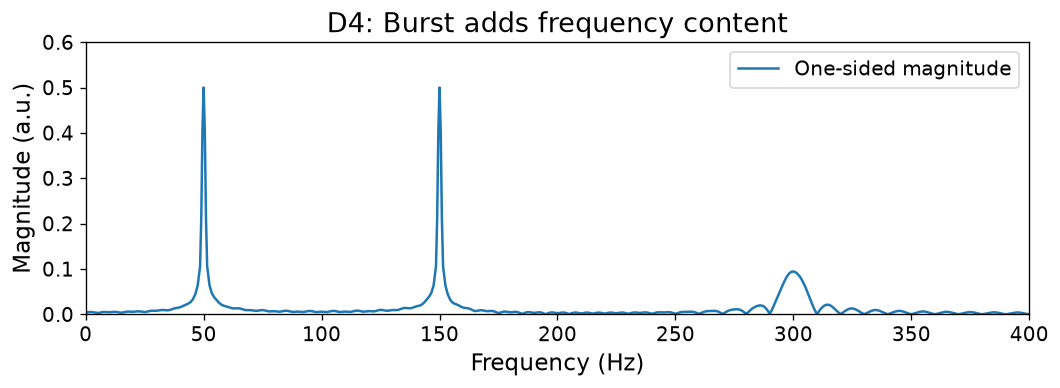

In [70]:
# Provided setup - run unchanged.
fig, ax = plt.subplots()
ax.plot(D4_fft_hz, D4_fft_magnitude, label='One-sided magnitude')
ax.set(title='D4: Burst adds frequency content', xlabel='Frequency (Hz)', ylabel='Magnitude (a.u.)',
       xlim=(0, 400), ylim=(0, 0.6))
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

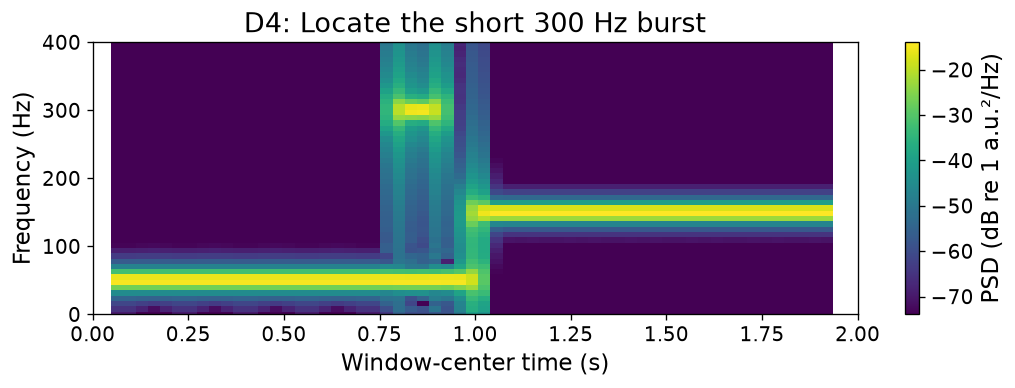

In [71]:
# Provided setup - run unchanged.
# A fixed 60 dB display span makes weak structure visible.
color_max = np.max(D4_db)
fig, ax = plt.subplots()
image = ax.pcolormesh(D4_time, D4_hz, D4_db, shading='auto',
                      vmin=color_max-60, vmax=color_max, rasterized=True)
ax.set(title='D4: Locate the short 300 Hz burst', xlabel='Window-center time (s)', ylabel='Frequency (Hz)',
       xlim=(0, 2), ylim=(0, 400))
fig.colorbar(image, ax=ax, label='PSD (dB re 1 a.u.²/Hz)')
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** A brief 300 Hz band is visible near 0.8–0.9 s. The FFT contains added content around 300 Hz but does not assign its timing. The spectrogram localizes the burst, with window-related spread. A short burst naturally spreads in frequency; it is not a perfectly isolated line or proof of a fault.

<a id="d5"></a>

## D5 - [COMPARE] Short versus long analysis windows

Run the supplied comparison on the same burst-containing signal. Compare transition timing, burst duration on the plot, and band sharpness. Which window helps each question? Both window length and hop change.

In [72]:
# Provided setup - run unchanged.
# A fresh copy prevents repeated runs from adding multiple bursts.
D5_signal = baseline.copy()
# Samples 800:900 span [0.80, 0.90) s; stop index 900 is excluded.
D5_signal[800:900] += np.sin(2 * np.pi * 300 * time_s[800:900])

In [73]:
# Provided setup - run unchanged.
# One window contains 64 samples; the hop is 16 samples.
# Global centering retains within-record changes; no per-frame detrending.
D5_short_centered = D5_signal - np.mean(D5_signal)
# SciPy returns Hz, window-center time (s), and PSD (a.u.²/Hz).
D5_short_hz, D5_short_time, D5_short_psd = spectrogram(
    D5_short_centered, fs=fs, window='hann', nperseg=64, noverlap=48,
    nfft=64, detrend=False, scaling='density', mode='psd')
# The floor avoids log(0); dB is relative to 1 a.u.²/Hz, not each plot's maximum.
D5_short_db = 10 * np.log10(np.maximum(D5_short_psd, 1e-20))

In [74]:
# Provided setup - run unchanged.
# One window contains 256 samples; the hop is 64 samples.
# Global centering retains within-record changes; no per-frame detrending.
D5_long_centered = D5_signal - np.mean(D5_signal)
# SciPy returns Hz, window-center time (s), and PSD (a.u.²/Hz).
D5_long_hz, D5_long_time, D5_long_psd = spectrogram(
    D5_long_centered, fs=fs, window='hann', nperseg=256, noverlap=192,
    nfft=256, detrend=False, scaling='density', mode='psd')
# The floor avoids log(0); dB is relative to 1 a.u.²/Hz, not each plot's maximum.
D5_long_db = 10 * np.log10(np.maximum(D5_long_psd, 1e-20))

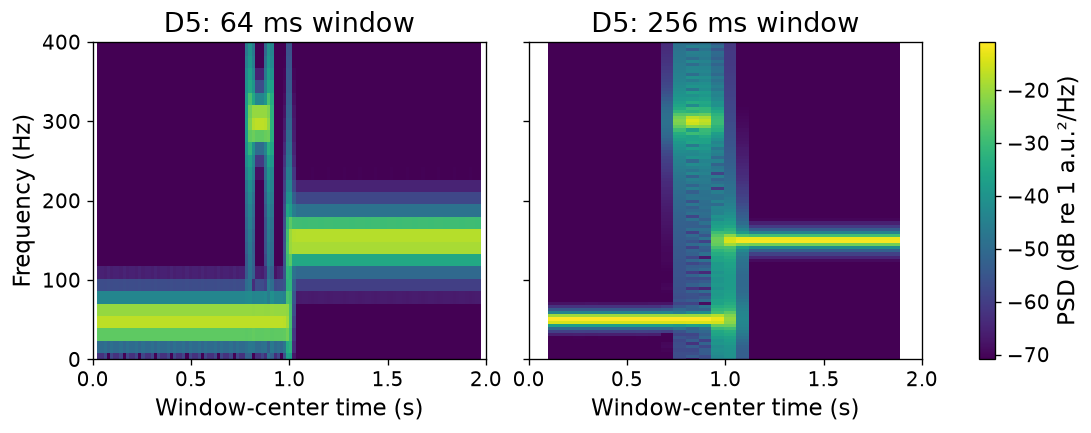

In [75]:
# Provided setup - run unchanged.
# Both panels use ONE color range; neither is normalized independently.
color_max = max(np.max(D5_short_db), np.max(D5_long_db))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5), sharex=True, sharey=True,
                               layout='constrained')
image1 = ax1.pcolormesh(D5_short_time, D5_short_hz, D5_short_db, shading='auto',
                       vmin=color_max-60, vmax=color_max, rasterized=True)
image2 = ax2.pcolormesh(D5_long_time, D5_long_hz, D5_long_db, shading='auto',
                       vmin=color_max-60, vmax=color_max, rasterized=True)
ax1.set(title='D5: 64 ms window', xlabel='Window-center time (s)', ylabel='Frequency (Hz)',
        xlim=(0, 2), ylim=(0, 400))
ax2.set(title='D5: 256 ms window', xlabel='Window-center time (s)',
        xlim=(0, 2), ylim=(0, 400))
fig.colorbar(image2, ax=[ax1, ax2], label='PSD (dB re 1 a.u.²/Hz)')
plt.show()

**Self-check - one possible answer.** The 64 ms window places transitions/bursts in narrower time intervals but produces broader frequency bands. The 256 ms window sharpens frequency structure while spreading event timing; it is longer than the 100 ms burst. Hops also change (16 vs 64 ms), and bin spacings are 15.625 vs 3.90625 Hz. These are observed analysis tradeoffs, not a universal best window.

<a id="module-e"></a>

# Module E - Features, Correlation, and Redundancy

Relevance asks how a feature relates to wear. Redundancy asks whether two
features repeat similar information. Engineering usefulness also needs sensor
meaning, operating context and validation. These are different questions.

Hypothetical cards: A is a sensor-fluctuation descriptor; B is a near-duplicate
readout of it; C can change direction across operating regimes; D is a nuisance
readout. These are teaching assumptions, not established physical mechanisms.
Features are dimensionless descriptors shown in a.u.; wear is hypothetical µm.

`table['column']` selects one column. `series.corr(other)` returns Pearson r:
its sign gives linear direction and |r| indicates linear strength. It does not
establish causation. The table is supplied; no pandas construction task is required.

**Start here:** run this module's setup, then any selected exercise. No earlier module or exercise answer is needed.

In [76]:
# Provided setup - run unchanged.
import numpy as np
import matplotlib.pyplot as plt
# Supplied display settings: readable figures, without changing the data.
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.figsize'] = (9, 3.4)
plt.rcParams['figure.dpi'] = 120

In [77]:
# Provided setup - run unchanged.
import pandas as pd
# Ten literal rows form a transparent teaching table, not measured PHM data.
# wear is hypothetical micrometers; feature descriptors are arbitrary, uncalibrated units.
feature_table = pd.DataFrame()
feature_table['wear'] = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
feature_table['feature_A'] = [7, 11, 15, 19, 23, 27, 31, 35, 39, 43]
feature_table['feature_B'] = [14.2, 21.8, 30.1, 38., 45.9, 53.9, 62., 70.1, 77.8, 86.2]
feature_table['feature_C'] = [20.25, 12.25, 6.25, 2.25, .25, .25, 2.25, 6.25, 12.25, 20.25]
feature_table['feature_D'] = [4, -3, 1, 5, -2, -2, 5, 1, -3, 4]
# Explicit columns make it easy to see what each row contains.
print(feature_table.to_string(index=False))

 wear  feature_A  feature_B  feature_C  feature_D
   10          7       14.2      20.25          4
   20         11       21.8      12.25         -3
   30         15       30.1       6.25          1
   40         19       38.0       2.25          5
   50         23       45.9       0.25         -2
   60         27       53.9       0.25         -2
   70         31       62.0       2.25          5
   80         35       70.1       6.25          1
   90         39       77.8      12.25         -3
  100         43       86.2      20.25          4


<a id="e1"></a>

## E1 - [INTERPRET] Read a feature–target scatter

Describe the direction and strength of Feature A's relationship with wear. Identify which axis is the feature and which is the target.

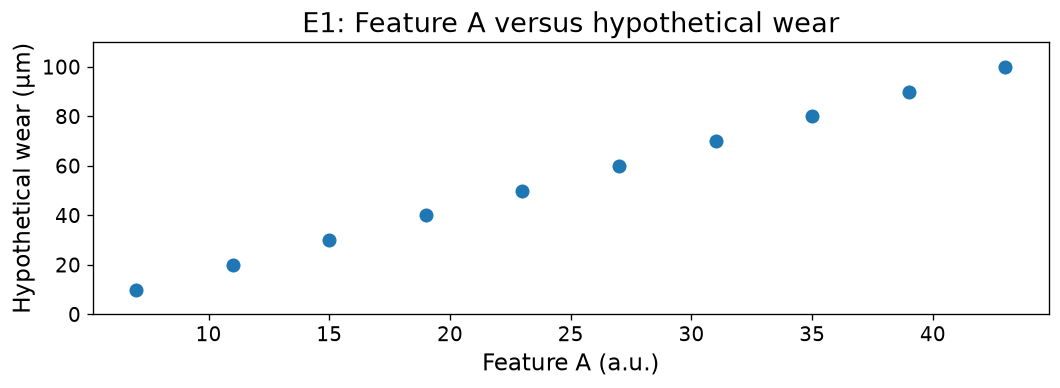

In [78]:
# Provided setup - run unchanged.
fig, ax = plt.subplots()
ax.scatter(feature_table['feature_A'], feature_table['wear'], s=55)
ax.set(title='E1: Feature A versus hypothetical wear', xlabel='Feature A (a.u.)',
       ylabel='Hypothetical wear (µm)', ylim=(0, 110))
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** Higher A accompanies higher wear in a strong positive linear pattern. A is on the horizontal axis and wear in µm on the vertical axis. This describes the constructed table; it does not show that A causes wear.

<a id="e2"></a>

## E2 - [COMPLETE] Complete one Pearson correlation

The supplied example correlates B with wear. Adapt it to A by completing one expression. Compare the number with the direction and shape visible in A's scatter.

In [79]:
# Provided setup - run unchanged.
# Worked example: two selected columns, one Pearson comparison.
example_r = feature_table['feature_B'].corr(feature_table['wear'])
print('B versus wear: r =', round(example_r, 6))

B versus wear: r = 0.999981


In [80]:
# r_A is dimensionless and describes linear association, not causation.
r_A = feature_table['feature_A'].corr(feature_table['wear'])

In [81]:
# Provided setup - run unchanged.
if r_A is None:
    print('E2: enter the A-versus-wear correlation expression.')
else:
    print('A versus wear: r =', round(r_A, 6))

A versus wear: r = 1.0


**Self-check - one possible answer.** A/wear has r = 1. B/wear has r ≈ 0.999981. The completed expression is `feature_table['feature_A'].corr(feature_table['wear'])`. A was constructed with a perfectly linear relation; high r does not establish a valid predictive model.

<a id="e3"></a>

## E3 - [COMPARE] Compare relevance and redundancy

Inspect A versus B and the supplied correlations. Why might keeping both add little information, even though each relates strongly to wear?

A/B r: 0.999981
A/wear r: 1.0


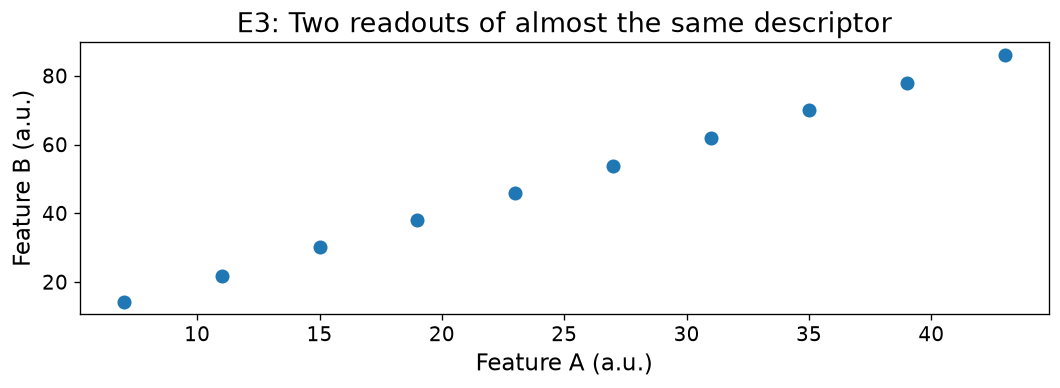

In [82]:
# Provided setup - run unchanged.
r_AB = feature_table['feature_A'].corr(feature_table['feature_B'])
print('A/B r:', round(r_AB, 6))
print('A/wear r:', round(feature_table['feature_A'].corr(feature_table['wear']), 6))
fig, ax = plt.subplots()
ax.scatter(feature_table['feature_A'], feature_table['feature_B'], s=55)
ax.set(title='E3: Two readouts of almost the same descriptor',
       xlabel='Feature A (a.u.)', ylabel='Feature B (a.u.)')
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** A and B form an almost straight line, with r ≈ 0.999981; B is approximately twice A. Both are relevant to wear in this example, but they largely repeat the same pattern. A different scale alone does not create new information or prove that the second feature improves prediction.

<a id="e4"></a>

## E4 - [INTERPRET] [DEBUG] Find a pattern Pearson r misses

Inspect C/wear and D/wear. Correct the statement **“r near zero proves no
relationship.”** With feature on x and wear on y, C makes a sideways U.
The faint line connects C observations in wear order only to guide your eye.

C/wear r: 0.0 | D/wear r: 0.0


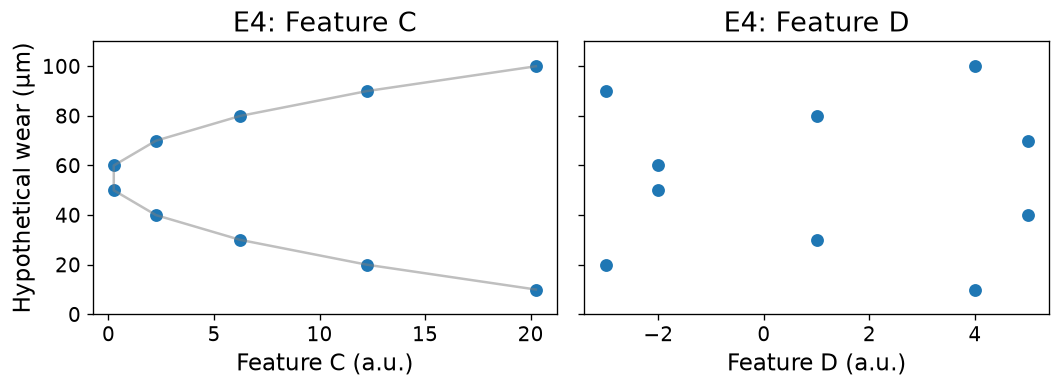

In [83]:
# Provided setup - run unchanged.
r_C = feature_table['feature_C'].corr(feature_table['wear'])
r_D = feature_table['feature_D'].corr(feature_table['wear'])
print('C/wear r:', round(r_C, 6), '| D/wear r:', round(r_D, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
ax1.plot(feature_table['feature_C'], feature_table['wear'], color='gray', alpha=0.5)
ax1.scatter(feature_table['feature_C'], feature_table['wear'], s=45)
ax2.scatter(feature_table['feature_D'], feature_table['wear'], s=45)
ax1.set(title='E4: Feature C', xlabel='Feature C (a.u.)',
        ylabel='Hypothetical wear (µm)', ylim=(0, 110))
ax2.set(title='E4: Feature D', xlabel='Feature D (a.u.)', ylim=(0, 110))
fig.tight_layout()
plt.show()

**Self-check - one possible answer.** Both Pearson values are zero, but C has a clear curved pattern. Pearson r summarizes linear association and can miss nonlinear structure. D shows no clear trend in these ten illustrative rows; zero r alone does not prove independence. C also cannot uniquely identify wear because two wear values can share the same C value.

**How this teaching table was made:** A = 3 + 0.4 × wear; B ≈ 2 × A
with small fixed perturbations; C = ((wear - 55)/10)²; D is a fixed nuisance
sequence. The definitions deliberately expose linear, redundant and nonlinear
patterns. In a real prediction problem, computing predictors from the target
would leak the answer; these constructions are not a valid wear-estimation method.

<a id="e5"></a>

## E5 - [SELECT] Choose two features and defend the tradeoff

Choose two distinct names from A–D. Explain relevance, redundancy and the hypothetical engineering meanings. Use the supplied standalone plots below. There is no unique correct answer; selecting the largest |r| values is not sufficient.

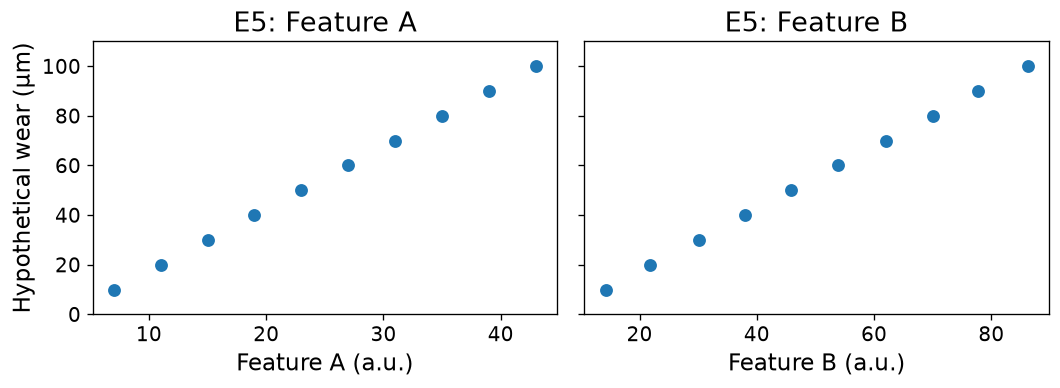

In [84]:
# Provided setup - run unchanged.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
ax1.scatter(feature_table['feature_A'], feature_table['wear'], s=45)
ax2.scatter(feature_table['feature_B'], feature_table['wear'], s=45)
ax1.set(title='E5: Feature A', xlabel='Feature A (a.u.)',
        ylabel='Hypothetical wear (µm)', ylim=(0, 110))
ax2.set(title='E5: Feature B', xlabel='Feature B (a.u.)', ylim=(0, 110))
fig.tight_layout()
plt.show()

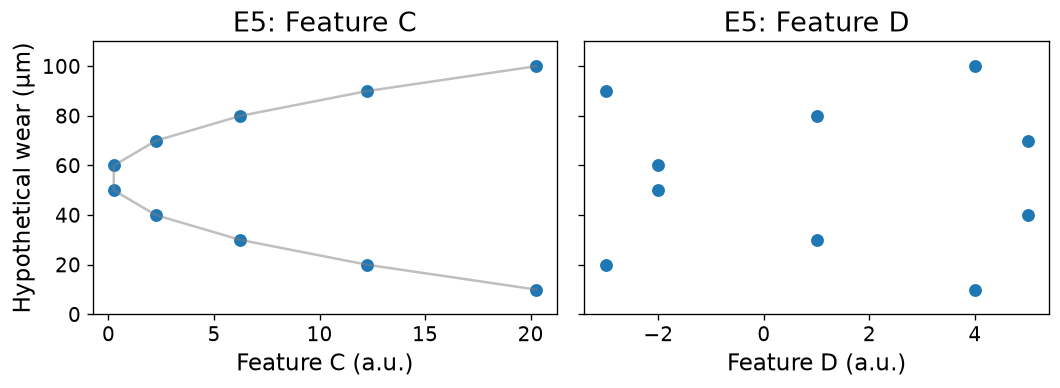

In [85]:
# Provided setup - run unchanged.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
ax1.plot(feature_table['feature_C'], feature_table['wear'], color='gray', alpha=0.5)
ax1.scatter(feature_table['feature_C'], feature_table['wear'], s=45)
ax2.scatter(feature_table['feature_D'], feature_table['wear'], s=45)
ax1.set(title='E5: Feature C', xlabel='Feature C (a.u.)',
        ylabel='Hypothetical wear (µm)', ylim=(0, 110))
ax2.set(title='E5: Feature D', xlabel='Feature D (a.u.)', ylim=(0, 110))
fig.tight_layout()
plt.show()

In [86]:
# One possible pair; other reasoned selections may also be valid.
selected_features = ['feature_A', 'feature_C']

In [87]:
# Provided setup - run unchanged.
if selected_features is None:
    print('E5: choose two names and explain your tradeoff.')
else:
    print('Your exploratory selection:', selected_features)

Your exploratory selection: ['feature_A', 'feature_C']


**Self-check - one possible answer.** One reasonable pair is A+C: A captures a strong linear pattern, while C adds a different regime-dependent shape without repeating B's near-copy of A. C is ambiguous by itself. B+C is another defensible choice; other pairs need a clear tradeoff. Actual sensor definitions, cost, operating conditions and grouped validation would be needed before claiming engineering usefulness or better prediction.

<a id="t1"></a>

## T1 - [TRANSFER] [INTERPRET] Optional PHM transfer

**Optional, about 10–15 extra minutes; outside all main route counts.**

Apply relevance/redundancy reasoning to the existing PHM master table. One row is
one complete recorded machining cut. It contains 945 cuts from three cutter groups,
c1/c4/c6, not 945 independent experimental replicates.

`force_x_sd` is sample SD of Force X (N); `vibration_x_sd` is sample SD of
Vibration X (g); both use ddof=1. `wear_mean_um` is mean wear across three original
flute measurements (µm). These are whole-record scalar features, not new windows
or an official supervised benchmark split.

PHM Society (2010), [original challenge](https://phmsociety.org/phm_competition/2010-phm-society-conference-data-challenge/).
See the [course feature README](https://github.com/WSU-AI-in-ME/ai-in-me-1/blob/main/data/phm2010/features/README.md)
and [dictionary](https://github.com/WSU-AI-in-ME/ai-in-me-1/blob/main/data/phm2010/features/DATA_DICTIONARY.md) for
source attribution, transformations and unresolved licensing details. The course
code license does not override the original data's rights.

**Opt in:** change `run_phm_transfer` to `True` only when you want this exercise.
Use a local course checkout or internet access to the existing public CSV. All
loading and plotting code is supplied. When disabled or unavailable, a skip
message appears; no synthetic data are substituted.

Compare the two feature–wear plots and the feature–feature plot. Use their Pearson
values, physical meanings and cutter colors to discuss relevance and overlap.
State one limitation. Neither feature is prescribed as best.

In [88]:
# Provided setup - run unchanged.
import numpy as np
import matplotlib.pyplot as plt
# Supplied display settings: readable figures, without changing the data.
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.figsize'] = (9, 3.4)
plt.rcParams['figure.dpi'] = 120

In [89]:
# Provided setup - run unchanged.
import pandas as pd
from pathlib import Path
from urllib.request import urlopen
from io import BytesIO
run_phm_transfer = False
# False makes default Run all independent of PHM files and network access.
phm = None
# This will hold one row per recorded cut only if loading succeeds.

In [90]:
# Provided setup - run unchanged.
if not run_phm_transfer:
    print('T1 skipped: set run_phm_transfer = True to try the optional PHM transfer.')
else:
    try:
        # Support running from the repository root or the practice/week03 folder.
        local_file = Path('data/phm2010/features/phm2010_features.csv')
        if not local_file.exists():
            local_file = Path('../../data/phm2010/features/phm2010_features.csv')
        if local_file.exists():
            phm = pd.read_csv(local_file)
            print('T1 input: existing local course feature table.')
        else:
            # A bounded request reads the existing CSV; it does not create a dataset.
            phm_url = 'https://raw.githubusercontent.com/WSU-AI-in-ME/ai-in-me-1/main/data/phm2010/features/phm2010_features.csv'
            with urlopen(phm_url, timeout=15) as response:
                phm = pd.read_csv(BytesIO(response.read()))
            print('T1 input: existing public course feature table.')
        # Select explicit required columns; missing columns trigger the skip handler.
        phm = phm[['cutter_id', 'force_x_sd', 'vibration_x_sd', 'wear_mean_um']]
        print('Loaded cuts:', len(phm), '| Cutter groups:', phm['cutter_id'].nunique())
    except (OSError, ValueError, KeyError):
        phm = None
        print('T1 unavailable: check your course checkout or internet connection; skipped.')

T1 skipped: set run_phm_transfer = True to try the optional PHM transfer.


In [91]:
# Provided setup - run unchanged.
if phm is not None:
    # These dimensionless coefficients are descriptive pooled associations.
    r_force_wear = phm['force_x_sd'].corr(phm['wear_mean_um'])
    r_vibration_wear = phm['vibration_x_sd'].corr(phm['wear_mean_um'])
    r_force_vibration = phm['force_x_sd'].corr(phm['vibration_x_sd'])
    print('Force SD / wear r:', round(r_force_wear, 4))
    print('Vibration SD / wear r:', round(r_vibration_wear, 4))
    print('Force SD / vibration SD r:', round(r_force_vibration, 4))
    # Boolean masks select cuts from each cutter; plotting code is supplied.
    c1 = phm[phm['cutter_id'] == 'c1']
    c4 = phm[phm['cutter_id'] == 'c4']
    c6 = phm[phm['cutter_id'] == 'c6']

In [92]:
# Provided setup - run unchanged.
if phm is not None:
    fig, ax = plt.subplots()
    ax.scatter(c1['force_x_sd'], c1['wear_mean_um'], s=12, alpha=0.6, label='c1')
    ax.scatter(c4['force_x_sd'], c4['wear_mean_um'], s=12, alpha=0.6, label='c4')
    ax.scatter(c6['force_x_sd'], c6['wear_mean_um'], s=12, alpha=0.6, label='c6')
    ax.set(title='T1: Force variation and wear', xlabel='Force X sample SD (N)', ylabel='Mean flute wear (µm)')
    ax.legend(title='Cutter', loc='best')
    fig.tight_layout()
    plt.show()

In [93]:
# Provided setup - run unchanged.
if phm is not None:
    fig, ax = plt.subplots()
    ax.scatter(c1['vibration_x_sd'], c1['wear_mean_um'], s=12, alpha=0.6, label='c1')
    ax.scatter(c4['vibration_x_sd'], c4['wear_mean_um'], s=12, alpha=0.6, label='c4')
    ax.scatter(c6['vibration_x_sd'], c6['wear_mean_um'], s=12, alpha=0.6, label='c6')
    ax.set(title='T1: Vibration variation and wear', xlabel='Vibration X sample SD (g)', ylabel='Mean flute wear (µm)')
    ax.legend(title='Cutter', loc='best')
    fig.tight_layout()
    plt.show()

In [94]:
# Provided setup - run unchanged.
if phm is not None:
    fig, ax = plt.subplots()
    ax.scatter(c1['force_x_sd'], c1['vibration_x_sd'], s=12, alpha=0.6, label='c1')
    ax.scatter(c4['force_x_sd'], c4['vibration_x_sd'], s=12, alpha=0.6, label='c4')
    ax.scatter(c6['force_x_sd'], c6['vibration_x_sd'], s=12, alpha=0.6, label='c6')
    ax.set(title='T1: Feature overlap across cutters', xlabel='Force X sample SD (N)', ylabel='Vibration X sample SD (g)')
    ax.legend(title='Cutter', loc='best')
    fig.tight_layout()
    plt.show()

**Self-check - one possible answer.** For the supplied 945-row table, the pooled correlations are approximately 0.8945 (force SD/wear), 0.9067 (vibration SD/wear), and 0.8094 (force SD/vibration SD). Both features have positive wear associations and substantial overlap; the slightly larger vibration correlation does not establish a better predictor. Force SD (N) and vibration SD (g) describe different physical signals and cannot be compared by raw numerical scale. Cutter-colored trajectories differ, so pooled r mixes within- and between-cutter variation. Three cutter groups limit generalization; this establishes neither causation nor unseen-cutter performance. Future fitted preprocessing and feature selection must use training data with appropriate grouping. If T1 is skipped, these reference values are not results from your current run.

## Personal self-check

Rendered notebook checkboxes are not clickable. To record completion, edit this
Markdown cell and change `[ ]` to `[x]`.

- [ ] I attempted the exercises I chose before reading their solutions.
- [ ] I connected an observed change to one controlled parameter or assumption.
- [ ] I can distinguish scalar features, magnitude spectra and time-localized power.
- [ ] I used correlation cautiously and acknowledged uncertain engineering meaning.

You may stop here or revisit one module. This Practice is optional, ungraded and
normally not submitted. A successful Run all does not mean every exercise was attempted.

## References and data attribution

- [NumPy documentation](https://numpy.org/doc/stable/): arrays, mean, standard deviation and peak-to-peak.
- [SciPy FFT](https://docs.scipy.org/doc/scipy/reference/fft.html) and
  [spectrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html): supplied frequency/time-frequency processing.
- [pandas Series.corr](https://pandas.pydata.org/docs/reference/api/pandas.Series.corr.html): Pearson correlation.
- [Practice 1](https://github.com/WSU-AI-in-ME/ai-in-me-1/blob/main/practice/week01/practice01_python_fundamentals.ipynb)
  and [Practice 2](https://github.com/WSU-AI-in-ME/ai-in-me-1/blob/main/practice/week02/practice02_scientific_computing.ipynb): optional Python/scientific-computing reinforcement.
- PHM Society, [2010 PHM Society Conference Data Challenge](https://phmsociety.org/phm_competition/2010-phm-society-conference-data-challenge/).
  Optional T1 uses the existing [course-derived feature table](https://github.com/WSU-AI-in-ME/ai-in-me-1/blob/main/data/phm2010/features/README.md)
  and [data dictionary](https://github.com/WSU-AI-in-ME/ai-in-me-1/blob/main/data/phm2010/features/DATA_DICTIONARY.md).
  The repository's code license does not relicense third-party data; consult these provenance and rights notes.

Modules A–E are constructed teaching examples. T1's observed associations do not
reproduce an official PHM benchmark, establish causation or demonstrate predictive performance.